# Data Analysis V2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from scipy.stats import kurtosis, skew
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_regression
import shap
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)

DATA_PATH = "../Dataset/Processed/Merged_Dataset_yoy.csv"

PREDICTION_TARGETS = ["EBITDA", "Net_Income", "ROA"]
TEST_YEAR_CUTOFF = 2023
N_SPLITS = 5
LOOKBACK_DAYS = 365
MIN_WINDOW_OBS = 200

# Target A: winsor +-3 -> arcsinh c=0.5
WINSOR_CAP = 3.0
ARCSINH_C = 0.5
ARCSINH_CAP = float(np.arcsinh(WINSOR_CAP / ARCSINH_C))

# Target B: delta of winsorized size-normalized ratios
RATIO_WINSOR_Q = (0.005, 0.995)
DENOM_REL_FLOOR = 0.10
NUM = {"EBITDA": "EBITDA", "Net_Income": "Net_Income", "ROA": "Net_Income"}
DENOM = {"EBITDA": "Net_Sales", "Net_Income": "Net_Sales", "ROA": "Total_Assets"}

PRIOR_STATIC_COLS = [
    "Prior_EBITDA_SL", "Prior_NI_SL", "Prior_ROA",
    "Leverage", "Cash_Ratio", "Size_SL",
    "Prior_Net_Sales_SL", "Prior_OpEx_SL", "Prior_FCF_Per_Share_SL",
]
CATEGORICAL_FEATURES = ["MC_MIB", "MC_MID", "MC_SMALL"]

# Modeling frequency groups (MultiFreqLSTM / GroupedLSTM feature selection)
DAILY_FEATURES = [
    'Close_logret', 'Volume_log', 'DE10YT_Yield', 'IT10YT_Yield',
    'EURUSD_Close', 'EURUSD_Volume', 'FTMIB_Close', 'FTMIB_Volume',
    'GVZ_Close', 'Brent_Close', 'Brent_Volume', 'OVX_Close', 'VIX_Close',
    'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv', 'ff_HML', 'ff_Mom',
    'TTF_Gas_Close', 'NFCI',
]
MONTHLY_FEATURES = ['Euribor_3M', 'IT_Inflation', 'IT_Unemployment', 'PCOPPUSDM', 'PALUMUSDM']
QUARTERLY_FEATURES = ['IT_GDP']

print("Setup complete.")

Setup complete.


In [2]:
df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Company", "Date"]).reset_index(drop=True)
df["year"] = df["Date"].dt.year
df["Close_logret"] = df.groupby("Company")["Close"].transform(lambda x: np.log(x / x.shift(1)))
df["Volume_log"] = np.log1p(df["Volume"].clip(lower=0))

CONTINUOUS_FEATURES = [
    'Close', 'Volume', 'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M',
    'FTMIB_Close', 'FTMIB_Volume', 'GVZ_Close', 'IT10YT_Yield', 'IT_Inflation', 'IT_GDP',
    'IT_Unemployment', 'Brent_Close', 'Brent_Volume', 'OVX_Close', 'TTF_Gas_Close',
    'VIX_Close', 'Gold_Close', 'T5YIE', 'YC__level', 'YC__slope', 'YC__curv',
    'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_Mkt-RF', 'ff_HML', 'ff_Mom',
    'Close_logret', 'Volume_log',
]
FEATURES = CONTINUOUS_FEATURES + CATEGORICAL_FEATURES

print(f"Rows: {len(df):,} | Companies: {df['Company'].nunique()} | "
      f"Range: {df['Date'].min().date()} -> {df['Date'].max().date()}")

Rows: 615,937 | Companies: 186 | Range: 2009-09-18 -> 2025-12-30


## Target engineering

In [35]:
def build_yoy_panel(data, targets):
    recs = []
    for t in targets:
        sub = (data.loc[data[t].notna(), ["Company", "year", "Date", t]]
                  .sort_values(["Company", "year", "Date"])
                  .drop_duplicates(["Company", "year"], keep="last")  # last-row-wins, mirrors modeling
                  .sort_values(["Company", "year"]))
        prev_val = sub.groupby("Company")[t].shift(1)
        prev_year = sub.groupby("Company")["year"].shift(1)
        chain_ok = prev_val.notna() & (sub["year"].to_numpy() == prev_year.to_numpy() + 1)
        yoy = (sub[t] - prev_val) / (prev_val.abs() + 1e-8)
        recs.append(pd.DataFrame({
            "Company": sub["Company"].to_numpy(),
            "year": sub["year"].to_numpy(),
            "Date": sub["Date"].to_numpy(),
            "target": t,
            "yoy_ratio": np.where(chain_ok, yoy, np.nan),
        }))
    return pd.concat(recs, ignore_index=True)


panel_a = build_yoy_panel(df, PREDICTION_TARGETS)
panel_a["yoy_capped"] = panel_a["yoy_ratio"].clip(-WINSOR_CAP, WINSOR_CAP)
panel_a["yoy_arcsinh"] = np.arcsinh(panel_a["yoy_capped"] / ARCSINH_C)
panel_a = panel_a.sort_values(["Company", "target", "year"]).reset_index(drop=True)
ga = panel_a.groupby(["Company", "target"])
panel_a["yoy_asinh_prev"] = ga["yoy_arcsinh"].shift(1)

print(f"Target A: winsor +-{WINSOR_CAP:g} -> arcsinh c={ARCSINH_C} (range +-{ARCSINH_CAP:.3f})")
for t in PREDICTION_TARGETS:
    raw = panel_a.loc[panel_a["target"] == t, "yoy_ratio"].dropna()
    n_capped = int((raw.abs() > WINSOR_CAP).sum())
    v = panel_a.loc[panel_a["target"] == t, "yoy_arcsinh"].dropna()
    print(f"  {t:11s}: n={len(raw)}  capped {n_capped} ({100.0 * n_capped / len(raw):.2f}%) "
          f"-> arcsinh range [{v.min():.3f}, {v.max():.3f}]")

Target A: winsor +-3 -> arcsinh c=0.5 (range +-2.492)
  EBITDA     : n=2214  capped 132 (5.96%) -> arcsinh range [-2.492, 2.492]
  Net_Income : n=2275  capped 245 (10.77%) -> arcsinh range [-2.492, 2.492]
  ROA        : n=2270  capped 235 (10.35%) -> arcsinh range [-2.492, 2.492]


### Target B — delta of winsorized size-normalized ratio

In [4]:
def build_ratio_panel(data, targets, test_year_cutoff, winsorize=True):
    recs, n_den_dropped, bounds = [], {}, {}
    for t in targets:
        num, den = NUM[t], DENOM[t]
        sub = (data.loc[data[t].notna(), ["Company", "year", "Date", num, den]]
                  .sort_values(["Company", "year", "Date"])
                  .drop_duplicates(["Company", "year"], keep="last"))  # last-row-wins, mirrors modeling
        d = sub[den].astype(float)
        sub = sub.assign(_den=d)
        pos_med = sub.loc[sub["_den"] > 0].groupby("Company")["_den"].median()
        med = sub["Company"].map(pos_med)
        credible = (sub["_den"] > 0) & (sub["_den"] >= DENOM_REL_FLOOR * med)
        n_den_dropped[t] = int(((sub["_den"] > 0) & ~credible).sum())
        recs.append(pd.DataFrame({
            "Company": sub["Company"].to_numpy(),
            "year": sub["year"].to_numpy(),
            "Date": sub["Date"].to_numpy(),
            "target": t,
            "ratio": np.where(credible, sub[num].astype(float) / sub["_den"], np.nan),
        }))
    panel = pd.concat(recs, ignore_index=True)

    if winsorize:
        for t in targets:
            m = panel["target"] == t
            r_train = panel.loc[m & (panel["year"] <= test_year_cutoff), "ratio"].to_numpy(float)
            lo, hi = np.nanpercentile(r_train, [100 * RATIO_WINSOR_Q[0], 100 * RATIO_WINSOR_Q[1]])
            panel.loc[m, "ratio"] = np.clip(panel.loc[m, "ratio"], lo, hi)
            bounds[t] = (lo, hi)
    return panel, n_den_dropped, bounds


def add_delta_cols(panel):
    panel = panel.sort_values(["Company", "target", "year"]).reset_index(drop=True)
    g = panel.groupby(["Company", "target"])
    panel["ratio_prev"] = g["ratio"].shift(1)
    panel["d_ratio"] = panel["ratio"] - panel["ratio_prev"]
    panel["d_ratio_prev"] = g["d_ratio"].shift(1)
    return panel


panel_b, n_den_dropped, ratio_bounds = build_ratio_panel(df, PREDICTION_TARGETS, TEST_YEAR_CUTOFF)
panel_b = add_delta_cols(panel_b)
panel_b_raw, _, _ = build_ratio_panel(df, PREDICTION_TARGETS, TEST_YEAR_CUTOFF, winsorize=False)
panel_b_raw = add_delta_cols(panel_b_raw)

print("Non-credible-denominator rows set NaN per target:", n_den_dropped)
for t in PREDICTION_TARGETS:
    lo, hi = ratio_bounds[t]
    print(f"  winsor[{t}] train-only bounds: [{lo:.4f}, {hi:.4f}]")

print("\nDelta-ratio (Target B) stats, full panel:")
for t in PREDICTION_TARGETS:
    v = panel_b.loc[panel_b["target"] == t, "d_ratio"].dropna().to_numpy(float)
    print(f"  {t:11s}: n={len(v)} mean={v.mean():+.4f} std={v.std():.4f} "
          f"MAD={np.mean(np.abs(v - np.median(v))):.4f} mean|d|={np.mean(np.abs(v)):.4f}")

Non-credible-denominator rows set NaN per target: {'EBITDA': 32, 'Net_Income': 39, 'ROA': 15}
  winsor[EBITDA] train-only bounds: [-1.7235, 0.9089]
  winsor[Net_Income] train-only bounds: [-2.4530, 0.7046]
  winsor[ROA] train-only bounds: [-0.4289, 0.2639]

Delta-ratio (Target B) stats, full panel:
  EBITDA     : n=2189 mean=+0.0044 std=0.1990 MAD=0.0836 mean|d|=0.0837
  Net_Income : n=2218 mean=+0.0021 std=0.2306 MAD=0.0879 mean|d|=0.0879
  ROA        : n=2255 mean=+0.0000 std=0.0705 MAD=0.0348 mean|d|=0.0349


## Target distributions

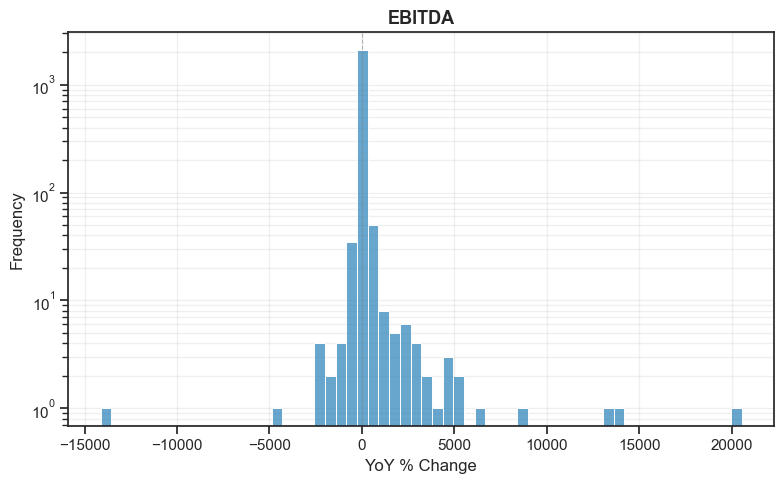

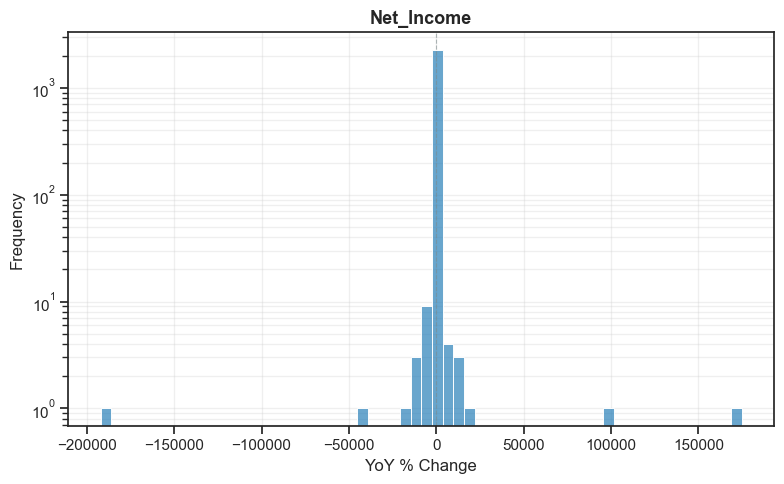

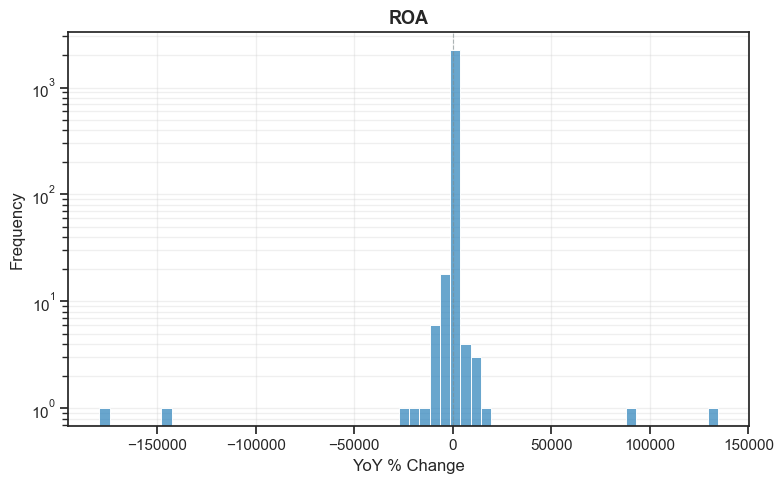

Raw YoY % change percentiles, full panel (no winsor, no transform):
  target             p0     p0.5       p1      p25      p50      p75      p99    p99.5     p100   n>±300%
  EBITDA      -1.41e+04     -967     -551    -13.1     9.24     35.2 2.05e+03 3.73e+03 2.06e+04   132
  Net_Income  -1.92e+05-3.84e+03-1.75e+03    -33.3     9.24     57.1 1.85e+03 3.08e+03 1.75e+05   245
  ROA         -1.79e+05-5.05e+03-1.81e+03    -37.7     2.29       48 1.73e+03 2.96e+03 1.35e+05   235


In [43]:
for t in PREDICTION_TARGETS:
    v = (panel_a.loc[panel_a["target"] == t, "yoy_ratio"]
         .replace([np.inf, -np.inf], np.nan).dropna() * 100.0)
    bins = np.linspace(v.min(), v.max(), 61)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(v, bins=bins, kde=False, ax=ax, color='#2980b9', alpha=0.7,
                 edgecolor='white', linewidth=0.5)
    ax.set_yscale('log')
    ax.axvline(0, color='#7f8c8d', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_title(f"{t}",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("YoY % Change")
    ax.set_ylabel("Frequency")
    ax.grid(True, which='both', alpha=0.3)
    ax.set_axisbelow(True)
    n_cap = int((v.abs() > WINSOR_CAP * 100).sum())

    plt.tight_layout()
    plt.show()

print(f"Raw YoY % change percentiles, full panel (no winsor, no transform):")
qs = [0, 0.5, 1, 25, 50, 75, 99, 99.5, 100]
print("  " + f"{'target':<12}" + "".join(f"  p{q:g}".rjust(9) for q in qs) + f"   n>±{WINSOR_CAP * 100:g}%")
for t in PREDICTION_TARGETS:
    v = (panel_a.loc[panel_a["target"] == t, "yoy_ratio"]
         .replace([np.inf, -np.inf], np.nan).dropna() * 100.0)
    pct = np.percentile(v, qs)
    print(f"  {t:<12}" + "".join(f"{x:>9.3g}" for x in pct) + f"   {int((v.abs() > WINSOR_CAP * 100).sum())}")

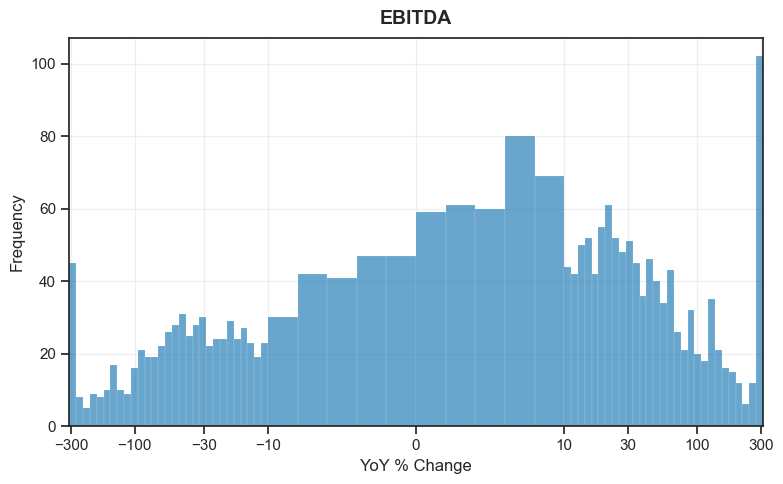

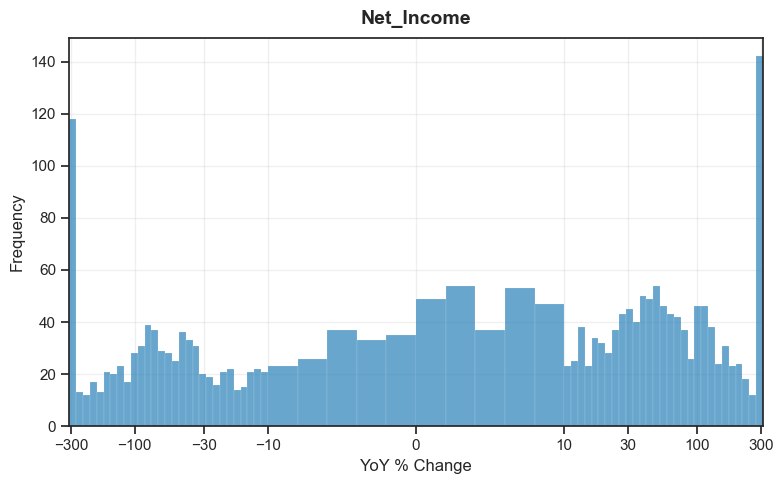

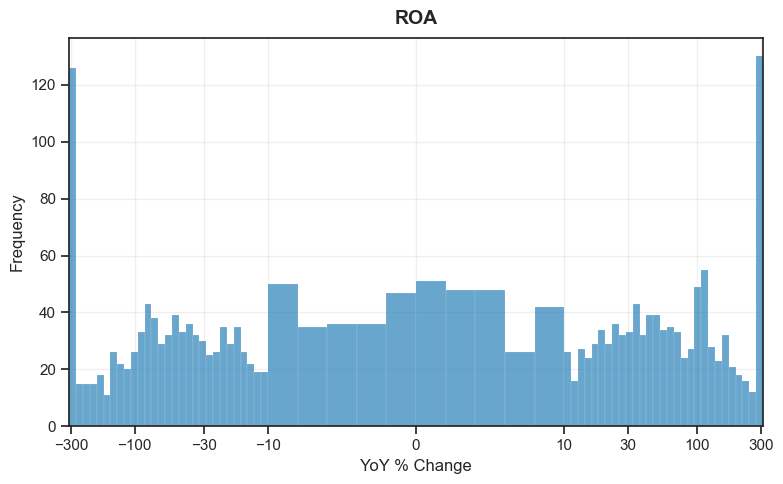

In [44]:
WINSOR_PCT = WINSOR_CAP * 100.0
EDGE_PAD = 10.0
PLOT_LIMIT = WINSOR_PCT + EDGE_PAD

SYMLIN_THRESH = 10.0


def symlog_bin_edges(lo, hi, linthresh, lin_step, n_log):
    lin = np.arange(-linthresh, linthresh + lin_step, lin_step)
    pos = np.geomspace(linthresh, hi, n_log)
    neg = -np.geomspace(linthresh, -lo, n_log)
    return np.unique(np.concatenate([neg, lin, pos]))


bin_edges = symlog_bin_edges(-PLOT_LIMIT, PLOT_LIMIT, SYMLIN_THRESH, 2.0, 30)

for t in PREDICTION_TARGETS:
    full = (panel_a.loc[panel_a["target"] == t, "yoy_ratio"]
            .replace([np.inf, -np.inf], np.nan).dropna() * 100.0)
    plot_data = full.clip(-PLOT_LIMIT, PLOT_LIMIT)
    n_outside = int((full.abs() > WINSOR_PCT).sum())
    pct_outside = 100.0 * n_outside / len(full)

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(plot_data, bins=bin_edges, kde=False, ax=ax, color='#2980b9', alpha=0.7,
                 edgecolor='white', linewidth=0.5)
    ax.set_xscale('symlog', linthresh=SYMLIN_THRESH)
    ax.set_xticks([-WINSOR_PCT, -100, -30, -10, 0, 10, 30, 100, WINSOR_PCT])
    ax.xaxis.set_major_formatter('{x:g}')
    ax.minorticks_off()
    ax.set_title(f"{t}", fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel("YoY % Change")
    ax.set_ylabel("Frequency")
    ax.set_xlim(-PLOT_LIMIT, PLOT_LIMIT)
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

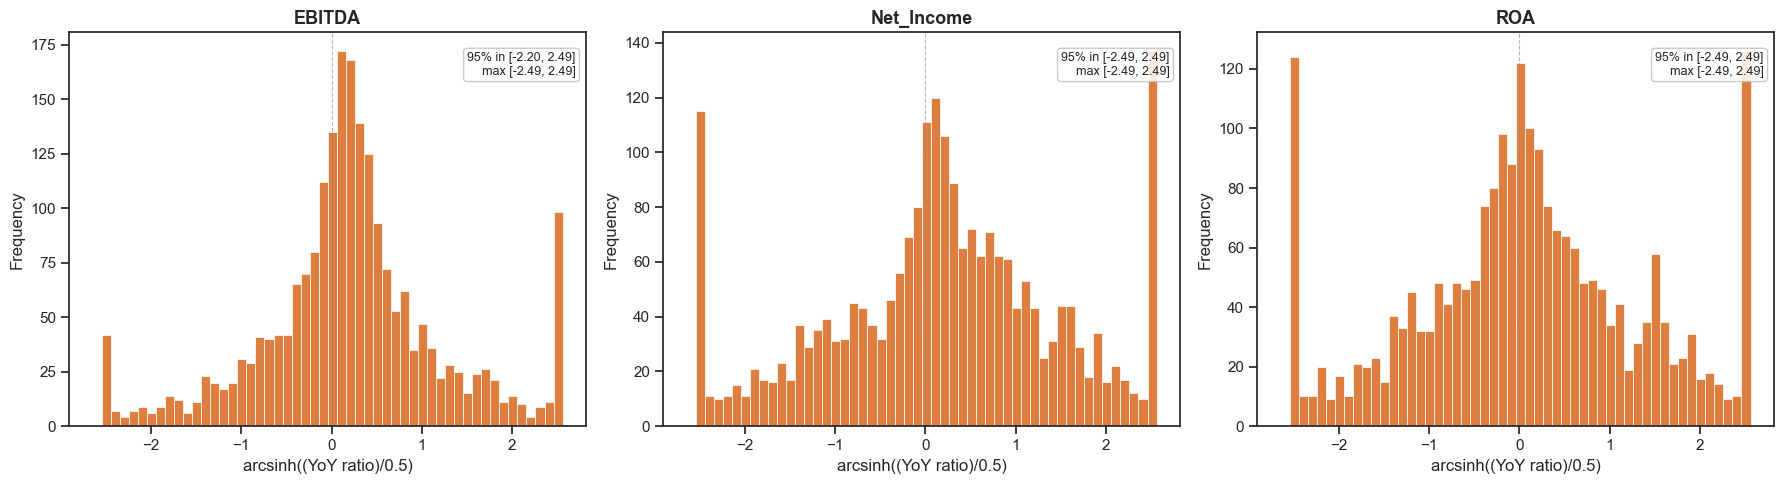

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bins = np.arange(-ARCSINH_CAP - 0.15, ARCSINH_CAP + 0.15, 0.1)

for i, t in enumerate(PREDICTION_TARGETS):
    v = panel_a.loc[panel_a["target"] == t, "yoy_arcsinh"].dropna()
    p_lo, p_hi = np.percentile(v, [2.5, 97.5])
    sns.histplot(v, bins=bins, kde=False, ax=axes[i], color='#d35400', alpha=0.75)
    axes[i].axvline(0, color='#7f8c8d', linewidth=0.8, linestyle='--', alpha=0.6)
    axes[i].set_title(f"{t}", fontsize=13, fontweight='bold')
    axes[i].set_xlabel("arcsinh((YoY ratio)/0.5)")
    axes[i].set_ylabel("Frequency")
    axes[i].text(0.98, 0.95,
                 f"95% in [{p_lo:.2f}, {p_hi:.2f}]\nmax [{v.min():.2f}, {v.max():.2f}]",
                 transform=axes[i].transAxes, ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#bdc3c7', alpha=0.85))

plt.tight_layout()
plt.show()

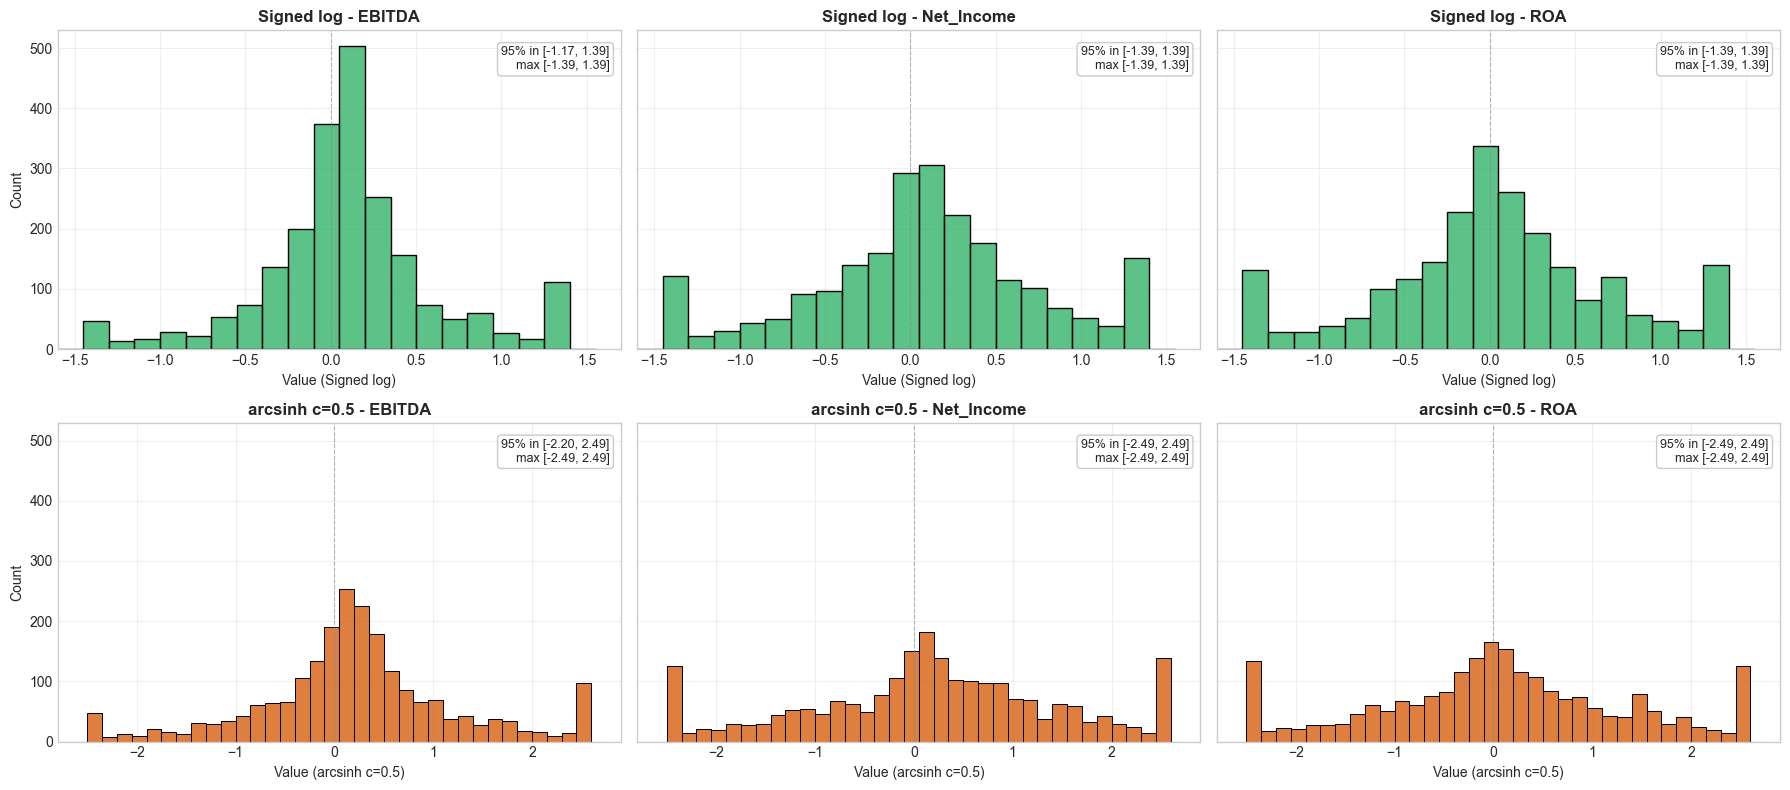

Shape comparison (signed log vs arcsinh on the same winsorized YoY data, plus Target B):

Target         View                  IQR      Std   Kurtosis     Skew
----------------------------------------------------------------------
EBITDA         signed log          0.424    0.525      1.391    0.061
EBITDA         arcsinh c=0.5       0.914    1.013      0.748   -0.028
EBITDA         delta ratio (B)     0.057    0.199     34.517    0.230

Net_Income     signed log          0.739    0.669      0.002   -0.168
Net_Income     arcsinh c=0.5       1.603    1.279     -0.374   -0.190
Net_Income     delta ratio (B)     0.045    0.231     49.055   -0.702

ROA            signed log          0.712    0.665      0.012   -0.060
ROA            arcsinh c=0.5       1.549    1.273     -0.374   -0.059
ROA            delta ratio (B)     0.027    0.070     17.196    0.771



In [8]:
ARCSINH_C_VALUES = [0.5]
FIXED_BW = 0.15

transformed_cols = {}
for t in PREDICTION_TARGETS:
    capped = panel_a.loc[panel_a["target"] == t, "yoy_capped"].dropna()
    transformed_cols[(t, "Signed log")] = np.sign(capped) * np.log1p(np.abs(capped))
    for c in ARCSINH_C_VALUES:
        transformed_cols[(t, f"arcsinh c={c}")] = np.arcsinh(capped / c)

rows = [("Signed log", '#27ae60', -1.6, 1.7),
        ("arcsinh c=0.5", '#d35400', -2.8, 2.9)]

fig, axes = plt.subplots(len(rows), 3, figsize=(18, 4.0 * len(rows)), sharex=False, sharey='all')
for r, (label, color, lo, hi) in enumerate(rows):
    b = np.arange(lo, hi, FIXED_BW)
    for i, t in enumerate(PREDICTION_TARGETS):
        ax = axes[r, i]
        data = pd.Series(transformed_cols[(t, label)])
        p_lo, p_hi = np.percentile(data, [2.5, 97.5])
        sns.histplot(data, bins=b, kde=False, ax=ax, color=color, alpha=0.75)
        ax.grid(True, alpha=0.3)
        ax.set_axisbelow(True)
        ax.set_title(f"{label} - {t}", fontsize=12, fontweight='bold')
        ax.set_xlim(lo, hi)
        ax.set_xlabel(f"Value ({label})")
        if i == 0:
            ax.set_ylabel('Count')
        else:
            ax.set_ylabel('')
        ax.text(0.98, 0.95, f"95% in [{p_lo:.2f}, {p_hi:.2f}]\nmax [{data.min():.2f}, {data.max():.2f}]",
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#bdc3c7', alpha=0.85))
        ax.axvline(0, color='#7f8c8d', linewidth=0.8, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print('Shape comparison (signed log vs arcsinh on the same winsorized YoY data, plus Target B):\n')
print(f"{'Target':<14} {'View':<16} {'IQR':>8} {'Std':>8} {'Kurtosis':>10} {'Skew':>8}")
print('-' * 70)
for t in PREDICTION_TARGETS:
    views = [("signed log", transformed_cols[(t, "Signed log")]),
             ("arcsinh c=0.5", transformed_cols[(t, "arcsinh c=0.5")]),
             ("delta ratio (B)", panel_b.loc[panel_b["target"] == t, "d_ratio"].dropna())]
    for name, s in views:
        s = pd.Series(s).astype(float)
        iqr = float(np.subtract(*np.percentile(s, [75, 25])))
        print(f"{t:<14} {name:<16} {iqr:>8.3f} {s.std():>8.3f} {kurtosis(s):>10.3f} {skew(s):>8.3f}")
    print()

In [8]:
print(f"Inverse map: real ratio = {ARCSINH_C}*sinh(x); local gradient d(real)/d(transformed) = {ARCSINH_C}*cosh(x).")
print("A fixed MAE in transformed space therefore corresponds to a LARGER real-space error for large |x|.\n")

rows = []
xs = [0.0, 0.5, 1.0, 1.5, 2.0, ARCSINH_CAP]
for x in xs:
    grad = ARCSINH_C * np.cosh(x)
    rows.append({
        "transformed x": round(x, 3),
        "real ratio": round(ARCSINH_C * np.sinh(x), 4),
        "gradient": round(grad, 3),
        "MAE 0.1 -> real": round(0.1 * grad, 4),
        "MAE 0.3 -> real": round(0.3 * grad, 4),
        "MAE 0.5 -> real": round(0.5 * grad, 4),
    })
print(pd.DataFrame(rows).to_string(index=False))
print("\nExample: at the winsor edge (x = +2.49, real ratio +3.0) an MAE of 0.3 in transformed")
print("space corresponds to a real-space ratio error of ~1.2 (120 percentage points of YoY change).")

Inverse map: real ratio = 0.5*sinh(x); local gradient d(real)/d(transformed) = 0.5*cosh(x).
A fixed MAE in transformed space therefore corresponds to a LARGER real-space error for large |x|.

 transformed x  real ratio  gradient  MAE 0.1 -> real  MAE 0.3 -> real  MAE 0.5 -> real
         0.000      0.0000     0.500           0.0500           0.1500           0.2500
         0.500      0.2605     0.564           0.0564           0.1691           0.2819
         1.000      0.5876     0.772           0.0772           0.2315           0.3858
         1.500      1.0646     1.176           0.1176           0.3529           0.5881
         2.000      1.8134     1.881           0.1881           0.5643           0.9405
         2.492      3.0000     3.041           0.3041           0.9124           1.5207

Example: at the winsor edge (x = +2.49, real ratio +3.0) an MAE of 0.3 in transformed
space corresponds to a real-space ratio error of ~1.2 (120 percentage points of YoY change).


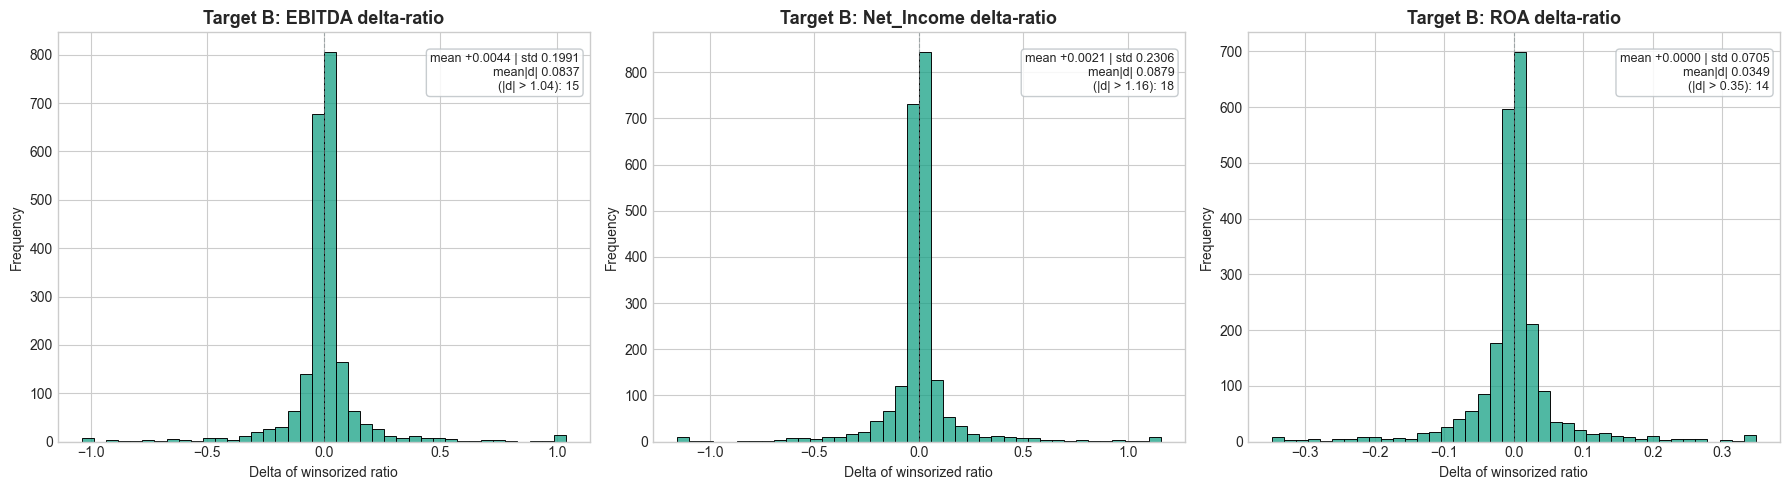

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, t in enumerate(PREDICTION_TARGETS):
    v = panel_b.loc[panel_b["target"] == t, "d_ratio"].dropna()
    lim = float(np.percentile(np.abs(v), 99)) * 1.1
    plot_v = v.clip(-lim, lim)
    n_out = int((v.abs() > lim).sum())
    sns.histplot(plot_v, bins=40, kde=False, ax=axes[i], color='#16a085', alpha=0.75)
    axes[i].axvline(0, color='#7f8c8d', linewidth=0.8, linestyle='--', alpha=0.6)
    axes[i].set_title(f"Target B: {t} delta-ratio", fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Delta of winsorized ratio")
    axes[i].set_ylabel("Frequency")
    axes[i].text(0.98, 0.95,
                 f"mean {v.mean():+.4f} | std {v.std():.4f}\nmean|d| {v.abs().mean():.4f}\n"
                 f"(|d| > {lim:.2f}): {n_out}",
                 transform=axes[i].transAxes, ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#bdc3c7', alpha=0.85))

plt.tight_layout()
plt.show()

## Macro lead–lag heatmaps (current targets)

In [10]:
def build_date_level_macro_timeline(df_input, feature_list):
    df_clean = df_input.copy()
    df_clean['Date'] = pd.to_datetime(df_clean['Date'])
    df_clean = df_clean.sort_values(by=['Company', 'Date']).reset_index(drop=True)

    date_level_features, company_level_features = [], []
    for feat in feature_list:
        max_nunique_per_date = df_clean.groupby('Date')[feat].nunique(dropna=True).max()
        if pd.isna(max_nunique_per_date) or max_nunique_per_date <= 1:
            date_level_features.append(feat)
        else:
            company_level_features.append(feat)

    if not date_level_features:
        raise ValueError("No date-level features found for lead-lag macro analysis.")

    macro_timeline = (
        df_clean[['Date'] + date_level_features]
        .drop_duplicates(subset=['Date'])
        .sort_values('Date')
        .set_index('Date')
        .ffill()
        .dropna()
        .sort_index()
    )
    return df_clean, macro_timeline, date_level_features, company_level_features


def plot_macro_lead_lag_heatmaps(df_input, feature_list, target_columns,
                                 trading_lags=None, trading_year=252,
                                 min_rolling_periods=200, min_samples=30,
                                 figsize=(18, 8), y_label="Macro date-level features"):
    if trading_lags is None:
        trading_lags = {0: '0M', 63: '3M', 126: '6M', 189: '9M', 252: '12M'}

    df_clean, macro_timeline, date_level_features, company_level_features = \
        build_date_level_macro_timeline(df_input, feature_list)

    macro_rolling_avg = macro_timeline.rolling(window=trading_year, min_periods=min_rolling_periods).mean()
    lag_labels = list(trading_lags.values())

    fig, axes = plt.subplots(1, len(target_columns), figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)

    for i, target_col in enumerate(target_columns):
        print(f"Processing Lead-Lag for: {target_col}...")
        heatmap_matrix = {feat: [] for feat in date_level_features}
        report_dates = df_clean[df_clean[target_col].notna()][['Date', target_col]].copy()

        for feat in date_level_features:
            for lag_bars in trading_lags.keys():
                shifted_macro = macro_rolling_avg[feat].shift(lag_bars + 1)
                aligned_df = report_dates.join(shifted_macro, on='Date', how='inner').dropna()
                if len(aligned_df) > min_samples:
                    corr = aligned_df[target_col].corr(aligned_df[feat], method='spearman')
                    heatmap_matrix[feat].append(corr)
                else:
                    heatmap_matrix[feat].append(np.nan)

        plot_df = pd.DataFrame(heatmap_matrix, index=lag_labels).T
        sns.heatmap(plot_df, annot=True, cmap='coolwarm', center=0, fmt=".2f",
                    linewidths=.5, cbar=(i == len(target_columns) - 1), ax=axes[i])
        axes[i].set_title(f"Lead-Lag: {target_col}", fontsize=13, fontweight='bold')
        axes[i].set_xlabel("Lag (Trading Months)")
        axes[i].set_ylabel(y_label if i == 0 else "")

    plt.tight_layout()
    plt.show()
    return date_level_features, company_level_features

Year-end rows with a valid target value:
  EBITDA_asinhYoy       : 2214
  Net_Income_asinhYoy   : 2275
  ROA_asinhYoy          : 2270
  EBITDA_deltaRatio     : 2189
  Net_Income_deltaRatio : 2218
  ROA_deltaRatio        : 2255

=== Lead-lag vs Target A (arcsinh YoY) ===
Processing Lead-Lag for: EBITDA_asinhYoy...
Processing Lead-Lag for: Net_Income_asinhYoy...
Processing Lead-Lag for: ROA_asinhYoy...


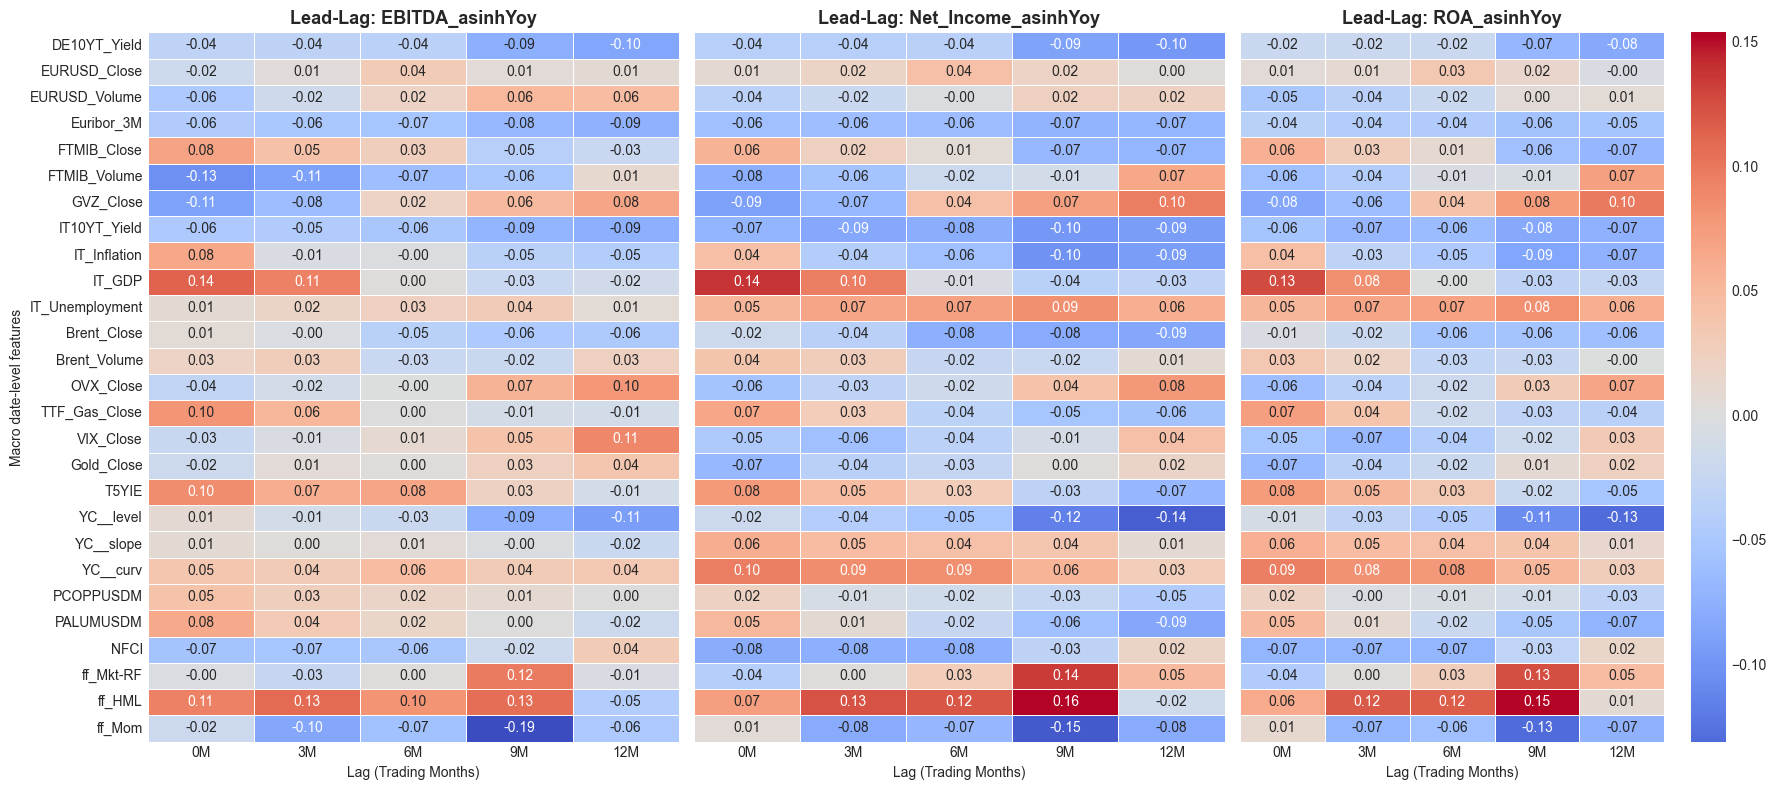


=== Lead-lag vs Target B (delta-ratio) ===
Processing Lead-Lag for: EBITDA_deltaRatio...
Processing Lead-Lag for: Net_Income_deltaRatio...
Processing Lead-Lag for: ROA_deltaRatio...


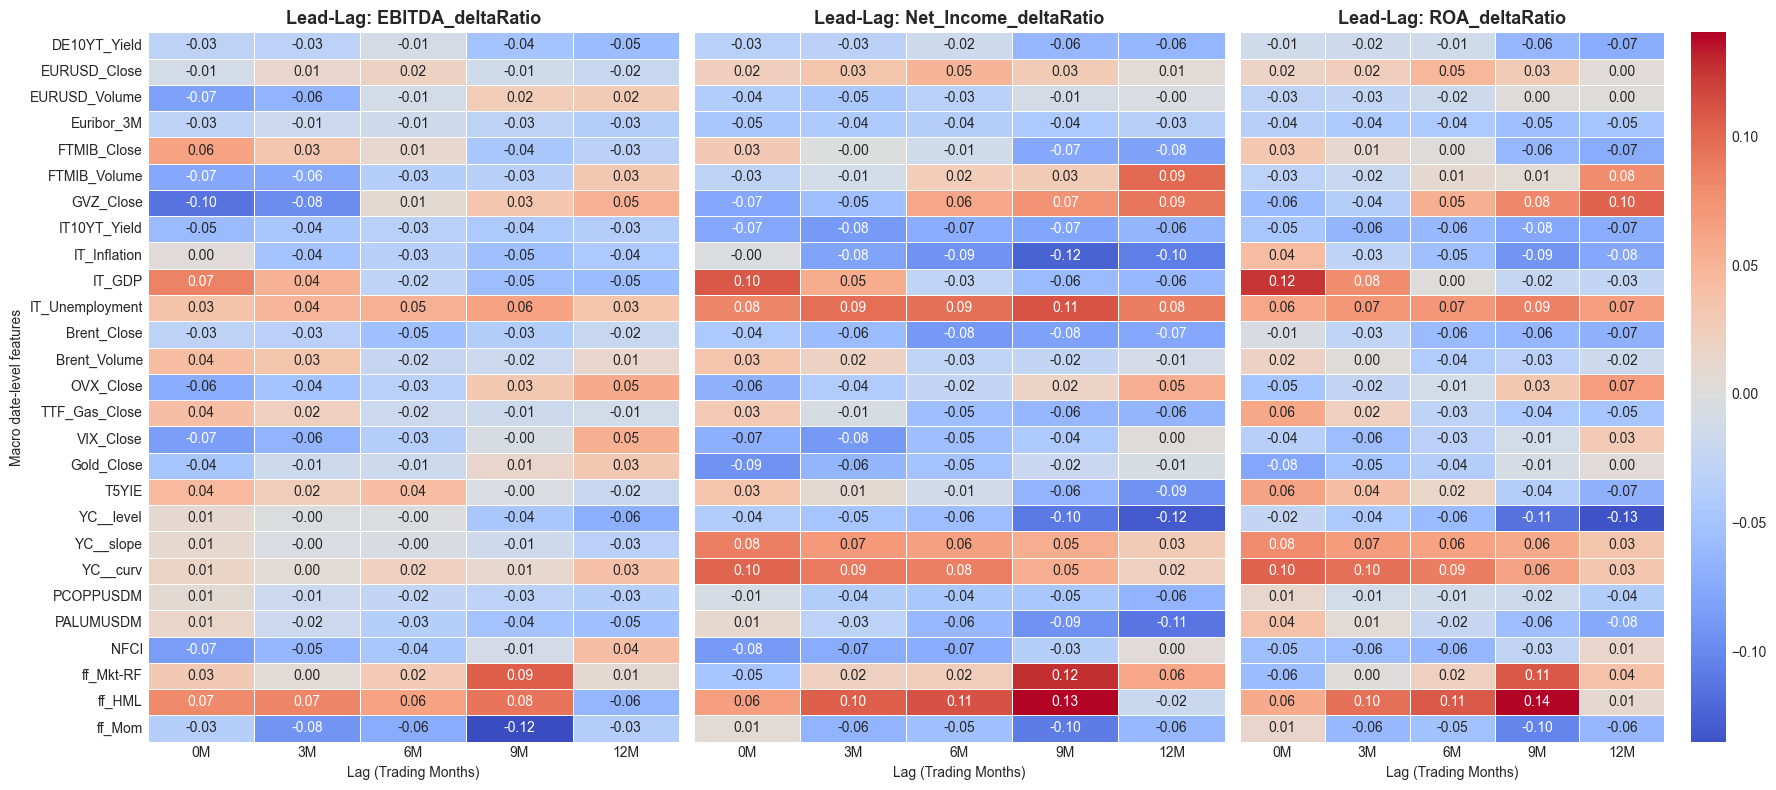

In [11]:
def attach_year_end_value(frame, panel, value_col, target, out_col):
    src = (panel.loc[panel["target"] == target, ["Company", "year", value_col]]
              .dropna(subset=[value_col]))
    ye_idx = frame.index[frame[target].notna()]
    key_df = frame.loc[ye_idx, ["Company", "year"]].copy()
    key_df["__row"] = np.asarray(ye_idx)
    key_df = key_df.drop_duplicates(["Company", "year"], keep="first")
    merged = key_df.merge(src, on=["Company", "year"], how="left")
    frame.loc[merged["__row"].to_numpy(), out_col] = merged[value_col].to_numpy()


df_ll = df.copy()
for t in PREDICTION_TARGETS:
    attach_year_end_value(df_ll, panel_a, "yoy_arcsinh", t, f"{t}_asinhYoy")
    attach_year_end_value(df_ll, panel_b, "d_ratio", t, f"{t}_deltaRatio")

asinh_cols = [f"{t}_asinhYoy" for t in PREDICTION_TARGETS]
delta_cols = [f"{t}_deltaRatio" for t in PREDICTION_TARGETS]
print("Year-end rows with a valid target value:")
for c in asinh_cols + delta_cols:
    print(f"  {c:22s}: {int(df_ll[c].notna().sum())}")

print("\n=== Lead-lag vs Target A (arcsinh YoY) ===")
_, _ = plot_macro_lead_lag_heatmaps(df_ll, FEATURES, asinh_cols)

print("\n=== Lead-lag vs Target B (delta-ratio) ===")
_, _ = plot_macro_lead_lag_heatmaps(df_ll, FEATURES, delta_cols)

## Global macro stress index

Total days analyzed: 4135
Date-level macro features used: 27
Maximum simultaneous shocks in one day: 16 features


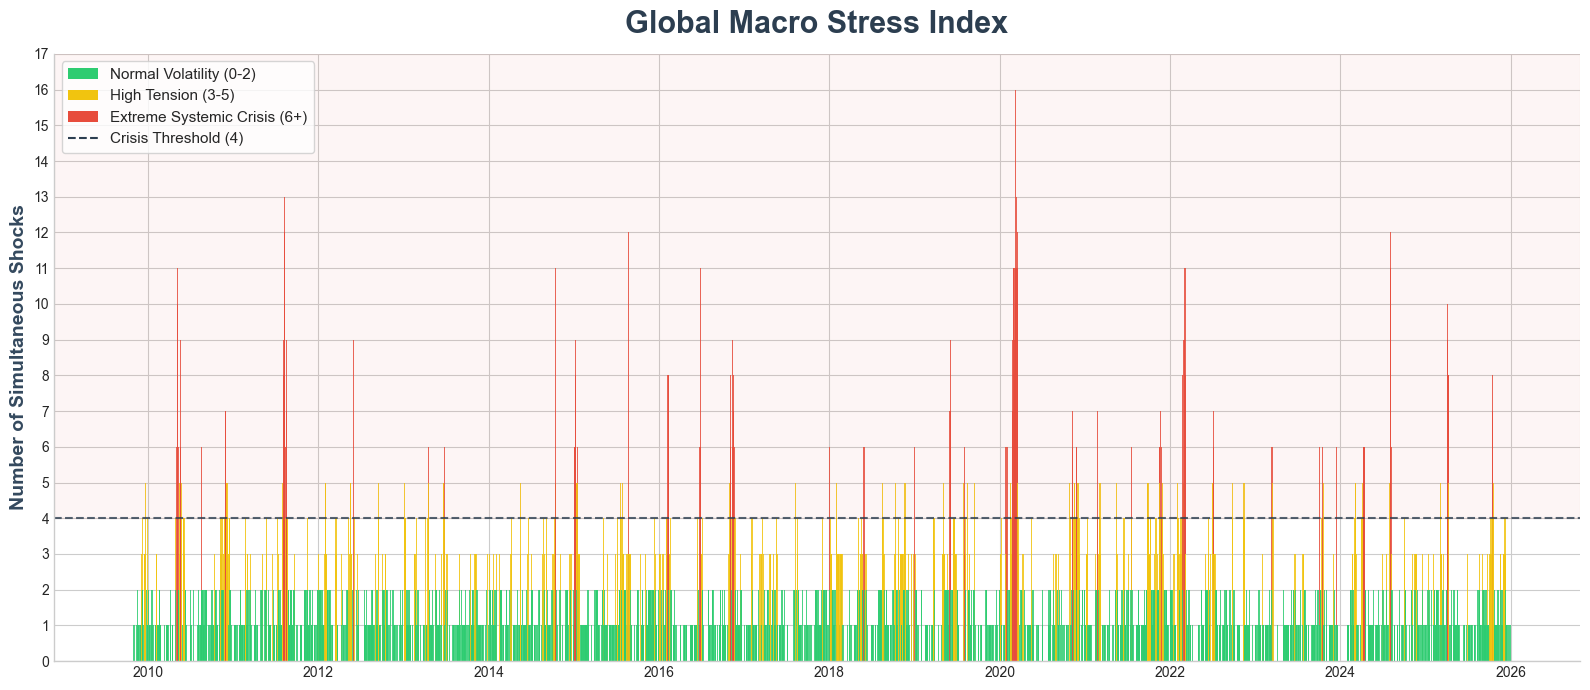


Top 5 Days with Highest Macro Stress:
- 2020-03-09: 16 simultaneous shocks (59.3% of features)
  Features: DE10YT_Yield, EURUSD_Close, EURUSD_Volume, FTMIB_Close, FTMIB_Volume, GVZ_Close, Brent_Close, Brent_Volume, OVX_Close, VIX_Close, T5YIE, YC__level, NFCI, ff_Mkt-RF, ff_HML, ff_Mom

- 2020-03-13: 13 simultaneous shocks (48.1% of features)
  Features: EURUSD_Volume, FTMIB_Close, FTMIB_Volume, GVZ_Close, IT10YT_Yield, Brent_Close, OVX_Close, VIX_Close, T5YIE, YC__slope, NFCI, ff_Mkt-RF, ff_HML

- 2011-08-08: 13 simultaneous shocks (48.1% of features)
  Features: DE10YT_Yield, FTMIB_Close, GVZ_Close, Brent_Close, OVX_Close, VIX_Close, Gold_Close, T5YIE, YC__level, YC__slope, NFCI, ff_Mkt-RF, ff_HML

- 2024-08-05: 12 simultaneous shocks (44.4% of features)
  Features: DE10YT_Yield, EURUSD_Volume, FTMIB_Close, GVZ_Close, Brent_Close, OVX_Close, VIX_Close, T5YIE, YC__level, YC__slope, YC__curv, ff_Mkt-RF

- 2015-08-24: 12 simultaneous shocks (44.4% of features)
  Features: EURUSD_Close,

In [12]:
TRADING_QUARTER = 63
Z_SCORE_THRESHOLD = 2.5

_, macro_daily, date_level_features, excluded_features = build_date_level_macro_timeline(df, FEATURES)
rolling_mean = macro_daily.rolling(window=TRADING_QUARTER, min_periods=30).mean()
rolling_std = macro_daily.rolling(window=TRADING_QUARTER, min_periods=30).std()

safe_std = rolling_std.replace(0, np.nan)
z_scores = (macro_daily - rolling_mean) / safe_std
z_scores = z_scores.replace([np.inf, -np.inf], np.nan)
anomalies_matrix = z_scores.abs() > Z_SCORE_THRESHOLD

global_stress_index = anomalies_matrix.sum(axis=1)
stress_ratio = global_stress_index / len(date_level_features)
stress_df = pd.DataFrame({'Stress_Score': global_stress_index, 'Stress_Ratio': stress_ratio})

print(f"Total days analyzed: {len(stress_df)}")
print(f"Date-level macro features used: {len(date_level_features)}")
print(f"Maximum simultaneous shocks in one day: {int(stress_df['Stress_Score'].max())} features")

fig, ax = plt.subplots(figsize=(16, 7))
colors = ['#2ecc71' if s < 3 else '#f1c40f' if s < 6 else '#e74c3c' for s in stress_df['Stress_Score']]
ax.bar(stress_df.index, stress_df['Stress_Score'], color=colors, width=4.0, alpha=0.85)

CRISIS_THRESHOLD = int(stress_df['Stress_Score'].quantile(0.95))
ax.axhline(y=CRISIS_THRESHOLD, color='#2c3e50', linestyle='--', linewidth=1.5, alpha=0.8)
ax.axhspan(CRISIS_THRESHOLD, stress_df['Stress_Score'].max() + 1, color='#e74c3c', alpha=0.05)

ax.set_title("Global Macro Stress Index", fontsize=22, fontweight='bold', color='#2c3e50', pad=15)
ax.set_ylabel("Number of Simultaneous Shocks", fontsize=14, color='#34495e', fontweight='bold')
ax.set_ylim(0, stress_df['Stress_Score'].max() + 0.5)
ax.set_yticks(range(0, int(stress_df['Stress_Score'].max()) + 2))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_elements = [
    Patch(facecolor='#2ecc71', label='Normal Volatility (0-2)'),
    Patch(facecolor='#f1c40f', label='High Tension (3-5)'),
    Patch(facecolor='#e74c3c', label='Extreme Systemic Crisis (6+)'),
    plt.Line2D([0], [0], color='#2c3e50', lw=1.5, linestyle='--', label=f'Crisis Threshold ({CRISIS_THRESHOLD})'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, frameon=True)
plt.tight_layout()
plt.show()

print("\nTop 5 Days with Highest Macro Stress:")
top_panic_days = stress_df.sort_values(by='Stress_Score', ascending=False).head(5)
for date, row in top_panic_days.iterrows():
    print(f"- {date.date()}: {int(row['Stress_Score'])} simultaneous shocks ({row['Stress_Ratio']:.1%} of features)")
    shocked_feats = anomalies_matrix.loc[date][anomalies_matrix.loc[date]].index.tolist()
    print(f"  Features: {', '.join(shocked_feats)}\n")

## Signal diagnostics: mean reversion of the delta ratio

In [13]:
def change_autocorr(panel, value_col):
    d = panel[["Company", "year", value_col]].dropna().sort_values(["Company", "year"]).copy()
    d["ch"] = d[value_col] - d.groupby("Company")[value_col].shift(1)
    d["ch_prev"] = d.groupby("Company")["ch"].shift(1)
    dd = d.dropna(subset=["ch_prev"])
    return float(np.corrcoef(dd["ch"], dd["ch_prev"])[0, 1]) if len(dd) > 2 else np.nan


rows = []
for t in PREDICTION_TARGETS:
    pb_raw = panel_b_raw[panel_b_raw["target"] == t]
    pb_win = panel_b[panel_b["target"] == t]
    ac_raw = change_autocorr(pb_raw, "ratio")
    ac_win = change_autocorr(pb_win, "ratio")

    dtr = pb_win.loc[pb_win["year"] <= TEST_YEAR_CUTOFF - 1, ["d_ratio", "d_ratio_prev"]].dropna()
    dte = pb_win.loc[pb_win["year"] > TEST_YEAR_CUTOFF, ["d_ratio", "d_ratio_prev"]].dropna()
    ar1 = LinearRegression().fit(dtr[["d_ratio_prev"]], dtr["d_ratio"])
    r2_train = float(ar1.score(dtr[["d_ratio_prev"]], dtr["d_ratio"]))
    mae_zero = float(np.mean(np.abs(dte["d_ratio"])))
    mae_ar1 = float(np.mean(np.abs(dte["d_ratio"] - ar1.predict(dte[["d_ratio_prev"]]))))
    rows.append({"Target": t, "Autocorr (raw)": ac_raw, "Autocorr (winsorized)": ac_win,
                 "AR(1) R2 (train)": r2_train,
                 "Test MAE zero-forecast": mae_zero, "Test MAE AR(1)": mae_ar1,
                 "n_test": len(dte)})

sig_df = pd.DataFrame(rows)
print(sig_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nReading: the winsorized autocorrelation (~ -0.3 to -0.4) is real but modest;")
print("the AR(1) forecast barely improves on the zero forecast out-of-sample - the bar")
print("the exogenous models must beat in section 7c.")

    Target  Autocorr (raw)  Autocorr (winsorized)  AR(1) R2 (train)  Test MAE zero-forecast  Test MAE AR(1)  n_test
    EBITDA         -0.2008                -0.3355            0.1500                  0.0658          0.0644     335
Net_Income         -0.1378                -0.3743            0.2093                  0.0615          0.0607     335
       ROA         -0.4188                -0.3073            0.0903                  0.0296          0.0292     335

Reading: the winsorized autocorrelation (~ -0.3 to -0.4) is real but modest;
the AR(1) forecast barely improves on the zero forecast out-of-sample - the bar
the exogenous models must beat in section 7c.


## Temporal splits matching the models

In [14]:
df_by_company = {c: g.sort_values("Date") for c, g in df.groupby("Company")}


def window_available(company, year_end_date):
    cdf = df_by_company.get(company)
    if cdf is None:
        return False
    start = year_end_date - pd.Timedelta(days=LOOKBACK_DAYS)
    w = cdf[(cdf["Date"] > start) & (cdf["Date"] <= year_end_date)]
    return len(w) >= MIN_WINDOW_OBS


def build_sample_frame(panel, value_col):
    wide = (panel.set_index(["Company", "year", "Date", "target"])[value_col]
                 .unstack("target").reset_index()
                 .rename(columns={"Date": "year_end_date"}))
    wide = wide[wide[PREDICTION_TARGETS].notna().all(axis=1)].reset_index(drop=True)
    wide["window_ok"] = [window_available(r.Company, r.year_end_date) for r in wide.itertuples()]
    wide = wide[wide["window_ok"]].reset_index(drop=True)
    return wide[["Company", "year", "year_end_date"] + PREDICTION_TARGETS]


samples_a = build_sample_frame(panel_a, "yoy_arcsinh")
samples_b = build_sample_frame(panel_b, "d_ratio")


def print_folds(samples, tag):
    years = sorted(int(y) for y in samples["year"].unique())
    pre = [y for y in years if y <= TEST_YEAR_CUTOFF]
    val_years = pre[-N_SPLITS:]
    n_test = int((samples["year"] > TEST_YEAR_CUTOFF).sum())
    print(f"{tag}: years {years}")
    print(f"  Test: > {TEST_YEAR_CUTOFF} ({n_test} samples)")
    print(f"  Expanding-window folds ({N_SPLITS}), val years: {val_years}")
    for i, vy in enumerate(val_years, 1):
        tr = int((samples["year"] < vy).sum())
        va = int((samples["year"] == vy).sum())
        print(f"    Fold {i}: train <= {vy - 1} ({tr}), val = {vy} ({va})")
    print(f"  Final split: train <= {TEST_YEAR_CUTOFF - 1} ({int((samples['year'] <= TEST_YEAR_CUTOFF - 1).sum())}), "
          f"val {TEST_YEAR_CUTOFF} ({int((samples['year'] == TEST_YEAR_CUTOFF).sum())}), "
          f"test > {TEST_YEAR_CUTOFF} ({n_test})")


print_folds(samples_a, "Target A (arcsinh-YoY, all 3 targets valid)")
print()
print_folds(samples_b, "Target B (delta-ratio, all 3 targets valid)")

Target A (arcsinh-YoY, all 3 targets valid): years [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
  Test: > 2023 (340 samples)
  Expanding-window folds (5), val years: [2019, 2020, 2021, 2022, 2023]
    Fold 1: train <= 2018 (1067), val = 2019 (144)
    Fold 2: train <= 2019 (1211), val = 2020 (151)
    Fold 3: train <= 2020 (1362), val = 2021 (155)
    Fold 4: train <= 2021 (1517), val = 2022 (163)
    Fold 5: train <= 2022 (1680), val = 2023 (171)
  Final split: train <= 2022 (1680), val 2023 (171), test > 2023 (340)

Target B (delta-ratio, all 3 targets valid): years [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
  Test: > 2023 (338 samples)
  Expanding-window folds (5), val years: [2019, 2020, 2021, 2022, 2023]
    Fold 1: train <= 2018 (1054), val = 2019 (141)
    Fold 2: train <= 2019 (1195), val = 2020 (148)
    Fold 3: train <= 2020 (1343), val = 2021 (154)
    Fold 4: train <= 2

## Random Forest baselines on the current targets

In [18]:
RF_PARAM_DISTRIBUTIONS = {
    'n_estimators': [400, 700, 1000, 1300],
    'max_depth': [None, 10, 16, 24, 32],
    'min_samples_split': [2, 4, 8, 12],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.5, 0.7, 1.0],
    'bootstrap': [True],
    'criterion': ['squared_error', 'absolute_error'],
}


def fit_rf(X_train, y_train):
    base_rf = RandomForestRegressor(random_state=SEED, oob_score=False)
    search = RandomizedSearchCV(
        estimator=base_rf,
        param_distributions=RF_PARAM_DISTRIBUTIONS,
        n_iter=35,
        cv=TimeSeriesSplit(n_splits=4),
        scoring='neg_mean_absolute_error',
        random_state=SEED,
        n_jobs=-1,
    )
    search.fit(X_train, y_train)
    return search.best_estimator_, search.best_params_


def regression_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    abs_err = np.abs(y_pred - y_true)
    return {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'R2': float(r2_score(y_true, y_pred)) if len(y_true) > 1 else np.nan,
        'WAPE': float(np.sum(abs_err) / max(np.sum(np.abs(y_true)), 1e-8) * 100.0),
    }


def compute_mutual_information(X_train, y_train, random_state=SEED):
    mi_scores = mutual_info_regression(X_train, y_train, random_state=random_state)
    return (pd.DataFrame({'Feature': X_train.columns, 'MI_Regression': mi_scores})
            .sort_values(by='MI_Regression', ascending=False).reset_index(drop=True), 'MI_Regression')


def asinh_inverse(x):
    return ARCSINH_C * np.sinh(x)


SECTOR_LIST = sorted(df["Sector"].dropna().astype(str).unique())
SECTOR_COLS = [f"Sector_{s}" for s in SECTOR_LIST]
print(f"Sectors ({len(SECTOR_LIST)}): {SECTOR_LIST}")


def extract_window_features(samples):
    records = []
    for row in samples.itertuples():
        cdf = df_by_company[row.Company]
        start = row.year_end_date - pd.Timedelta(days=LOOKBACK_DAYS)
        window = cdf[(cdf["Date"] > start) & (cdf["Date"] <= row.year_end_date)]
        stats = {"Company": row.Company, "year": row.year, "year_end_date": row.year_end_date,
                 "Random_Noise": float(np.random.normal(0, 1))}
        for feat in CONTINUOUS_FEATURES:
            s = window[feat].dropna()
            if s.empty:
                for suf in ("_MEAN", "_STD", "_LAST", "_TREND"):
                    stats[f"{feat}{suf}"] = np.nan
            else:
                v = s.to_numpy(float)
                stats[f"{feat}_MEAN"] = float(v.mean())
                stats[f"{feat}_STD"] = float(v.std(ddof=1)) if len(v) > 1 else np.nan
                stats[f"{feat}_LAST"] = float(v[-1])
                stats[f"{feat}_TREND"] = (float(np.polyfit(np.arange(len(v), dtype=float), v, 1)[0])
                                          if len(v) > 1 else np.nan)
        for feat in CATEGORICAL_FEATURES + PRIOR_STATIC_COLS:
            s = window[feat].dropna()
            stats[f"{feat}_LAST"] = float(s.iloc[-1]) if not s.empty else np.nan
        sec = window["Sector"].dropna()
        sec = str(sec.iloc[-1]) if not sec.empty else None
        for col in SECTOR_COLS:
            stats[col] = 1.0 if (sec is not None and col == f"Sector_{sec}") else 0.0
        records.append(stats)
    return pd.DataFrame(records)


META_COLS = ("Company", "year", "year_end_date", "__y", "__lag")


def run_rf_baseline(X_df, label, real_inverse=None, naive_lag_col=None, show_shap=True):
    X_df = X_df.sort_values("year_end_date").reset_index(drop=True)
    y = X_df["__y"].to_numpy(float)
    feat_cols = [c for c in X_df.columns if c not in META_COLS]
    years = X_df["year"].to_numpy()
    tr = years <= TEST_YEAR_CUTOFF - 1
    va = years == TEST_YEAR_CUTOFF
    te = years > TEST_YEAR_CUTOFF

    X_raw = X_df[feat_cols]
    imputer = SimpleImputer(strategy="median").fit(X_raw[tr])
    X = pd.DataFrame(imputer.transform(X_raw), columns=feat_cols, index=X_df.index)

    rf, best_params = fit_rf(X[tr], y[tr])
    pred_va, pred_te = rf.predict(X[va]), rf.predict(X[te])

    res = {"label": label, "n_train": int(tr.sum()), "n_val": int(va.sum()), "n_test": int(te.sum()),
           "best_params": best_params,
           "val": regression_metrics(y[va], pred_va),
           "test": regression_metrics(y[te], pred_te)}
    if real_inverse is not None:
        res["val_real"] = regression_metrics(real_inverse(y[va]), real_inverse(pred_va))
        res["test_real"] = regression_metrics(real_inverse(y[te]), real_inverse(pred_te))
    if naive_lag_col is not None:
        lag = X_df[naive_lag_col].to_numpy(float)
        ok_tr, ok_va, ok_te = tr & ~np.isnan(lag), va & ~np.isnan(lag), te & ~np.isnan(lag)
        ar1 = LinearRegression().fit(lag[ok_tr].reshape(-1, 1), y[ok_tr])
        res["naive"] = {
            "val": {"MAE_zero": float(np.mean(np.abs(y[va]))),
                    "MAE_AR1": float(np.mean(np.abs(y[ok_va] - ar1.predict(lag[ok_va].reshape(-1, 1))))),
                    "n_ar1": int(ok_va.sum())},
            "test": {"MAE_zero": float(np.mean(np.abs(y[te]))),
                     "MAE_AR1": float(np.mean(np.abs(y[ok_te] - ar1.predict(lag[ok_te].reshape(-1, 1))))),
                     "n_ar1": int(ok_te.sum())},
        }

    print(f"\n{'=' * 74}\n{label:^74}\n{'=' * 74}")
    print(f"samples: train={res['n_train']} (<= {TEST_YEAR_CUTOFF - 1}), "
          f"val={res['n_val']} ({TEST_YEAR_CUTOFF}), test={res['n_test']} (> {TEST_YEAR_CUTOFF})")
    print(f"best params: {best_params}")
    v, tt = res["val"], res["test"]
    print(f"val  -> MAE {v['MAE']:.4f} | RMSE {v['RMSE']:.4f} | R2 {v['R2']:+.4f} | WAPE {v['WAPE']:.1f}%")
    print(f"test -> MAE {tt['MAE']:.4f} | RMSE {tt['RMSE']:.4f} | R2 {tt['R2']:+.4f} | WAPE {tt['WAPE']:.1f}%")
    if real_inverse is not None:
        vr, tr2 = res["val_real"], res["test_real"]
        print(f"real space (0.5*sinh): val MAE {vr['MAE'] * 100:.1f}% | test MAE {tr2['MAE'] * 100:.1f}%")
    if "naive" in res:
        nv, nt = res["naive"]["val"], res["naive"]["test"]
        print(f"naive: zero-forecast MAE val {nv['MAE_zero']:.4f} / test {nt['MAE_zero']:.4f} | "
              f"AR(1) MAE val {nv['MAE_AR1']:.4f} / test {nt['MAE_AR1']:.4f} (n={nt['n_ar1']})")

    imp = (pd.DataFrame({"Feature": feat_cols, "Importance": rf.feature_importances_})
           .sort_values("Importance", ascending=False))
    print("top-8 Gini: " + ", ".join(f"{r.Feature} ({r.Importance:.3f})"
                                     for r in imp.head(8).itertuples()))

    plt.figure(figsize=(7, 7))
    plt.scatter(y[te], pred_te, alpha=0.6, color='teal', s=18)
    lo, hi = min(y[te].min(), pred_te.min()), max(y[te].max(), pred_te.max())
    plt.plot([lo, hi], [lo, hi], '--', color='crimson', linewidth=1.5)
    plt.title(f'Actual vs Predicted (test) - {label}', fontsize=13)
    plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    top = imp.head(25).sort_values(by='Importance')
    plt.figure(figsize=(12, 8))
    plt.barh(top['Feature'], top['Importance'], color='teal')
    plt.title(f'Top 25 Features (Gini) - {label}', fontsize=14)
    plt.xlabel('Gini Importance'); plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()

    mi_df, mi_col = compute_mutual_information(X[tr], y[tr])
    top_mi = mi_df.head(25).sort_values(by=mi_col)
    plt.figure(figsize=(12, 8))
    plt.barh(top_mi['Feature'], top_mi[mi_col], color='#1f77b4')
    plt.title(f'Top 25 Features (Mutual Information) - {label}', fontsize=14)
    plt.xlabel('Mutual Information Score'); plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()

    if show_shap:
        explainer = shap.TreeExplainer(rf)
        shap_values = explainer.shap_values(X[te], check_additivity=False)
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X[te], plot_type='dot', show=False)
        plt.title(f"SHAP Impact - {label}", fontsize=14)
        plt.tight_layout(); plt.show()

    return res

Sectors (10): ['Basic Materials', 'Consumer Cyclicals', 'Consumer Non-Cyclicals', 'Energy', 'Financials', 'Healthcare', 'Industrials', 'Real Estate', 'Technology', 'Utilities']



                       EBITDA (raw absolute level)                        
samples: train=1711 (<= 2022), val=172 (2023), test=343 (> 2023)
best params: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 24, 'criterion': 'absolute_error', 'bootstrap': True}
val  -> MAE 310663.7500 | RMSE 1171239.3790 | R2 +0.8876 | WAPE 29.4%
test -> MAE 330356.7079 | RMSE 1887674.4113 | R2 +0.6039 | WAPE 31.6%
top-8 Gini: Prior_EBITDA_SL_LAST (0.322), Prior_Net_Sales_SL_LAST (0.187), Prior_OpEx_SL_LAST (0.082), Prior_NI_SL_LAST (0.062), Size_SL_LAST (0.040), Volume_log_MEAN (0.032), Prior_ROA_LAST (0.032), Volume_MEAN (0.023)


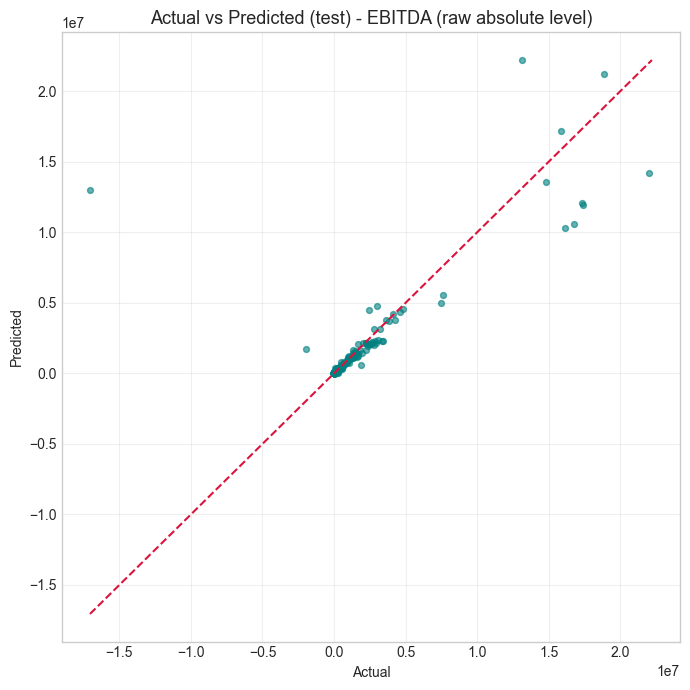

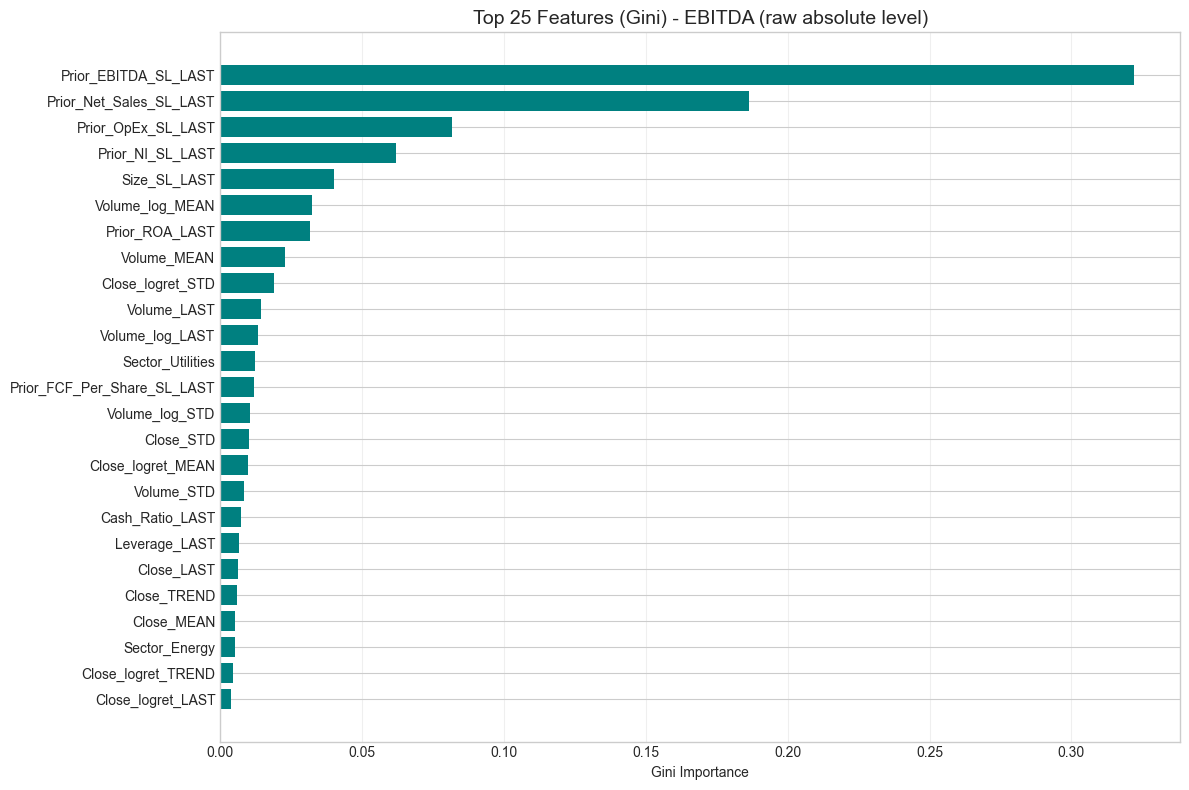

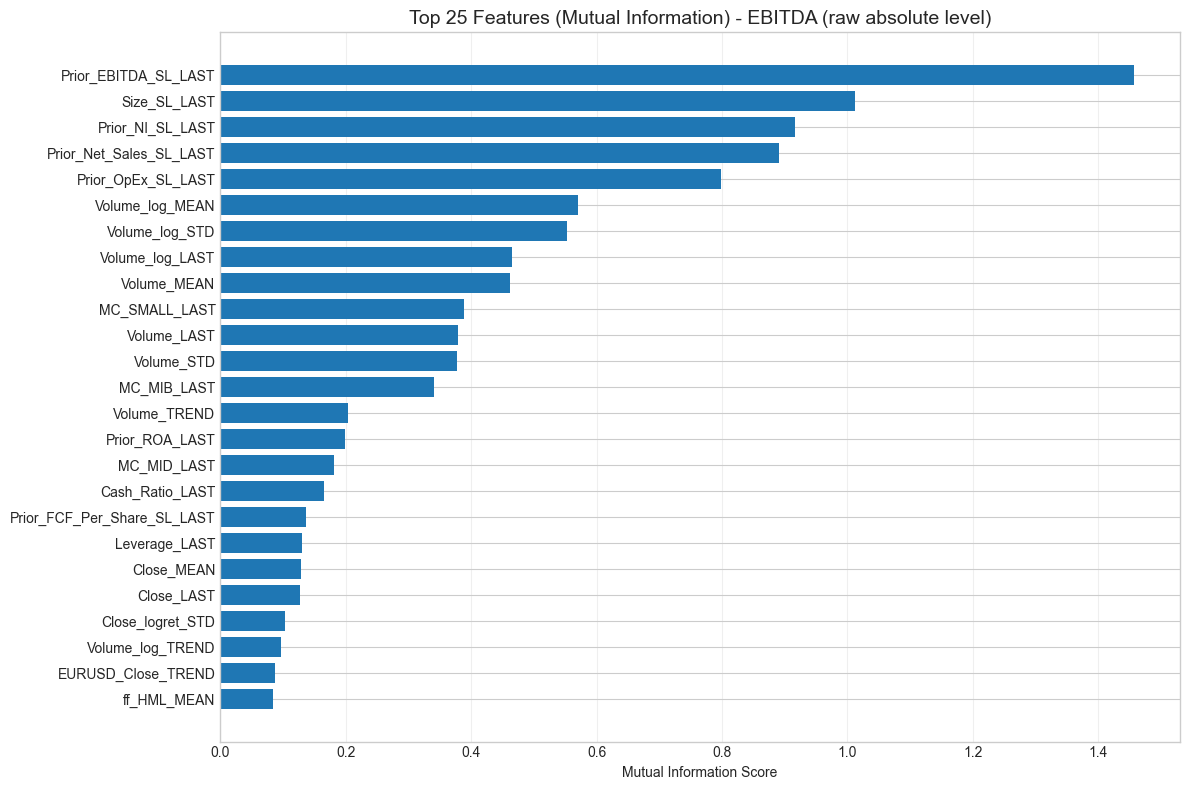

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_84565/562266529.py:170: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[te], plot_type='dot', show=False)


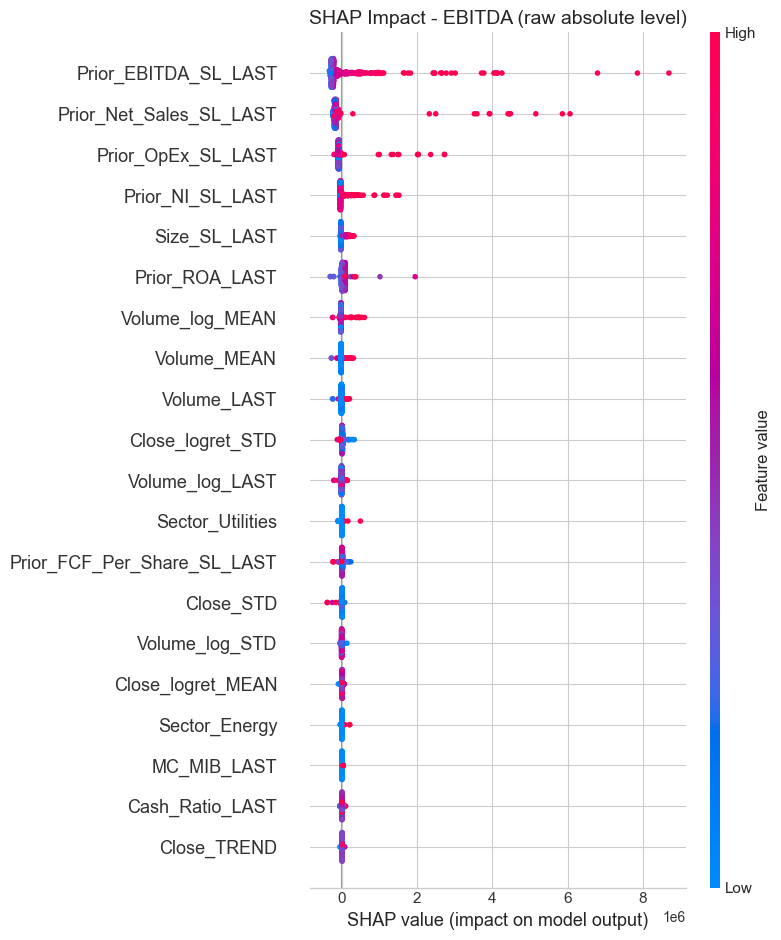


                     Net_Income (raw absolute level)                      
samples: train=1745 (<= 2022), val=172 (2023), test=344 (> 2023)
best params: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 32, 'criterion': 'absolute_error', 'bootstrap': True}
val  -> MAE 245244.7090 | RMSE 1139698.4676 | R2 +0.6012 | WAPE 48.8%
test -> MAE 245578.6797 | RMSE 1570894.0997 | R2 +0.2052 | WAPE 49.6%
top-8 Gini: Prior_NI_SL_LAST (0.354), Prior_EBITDA_SL_LAST (0.126), Prior_OpEx_SL_LAST (0.061), Prior_Net_Sales_SL_LAST (0.057), Size_SL_LAST (0.047), Close_logret_MEAN (0.032), Close_logret_STD (0.030), Prior_ROA_LAST (0.026)


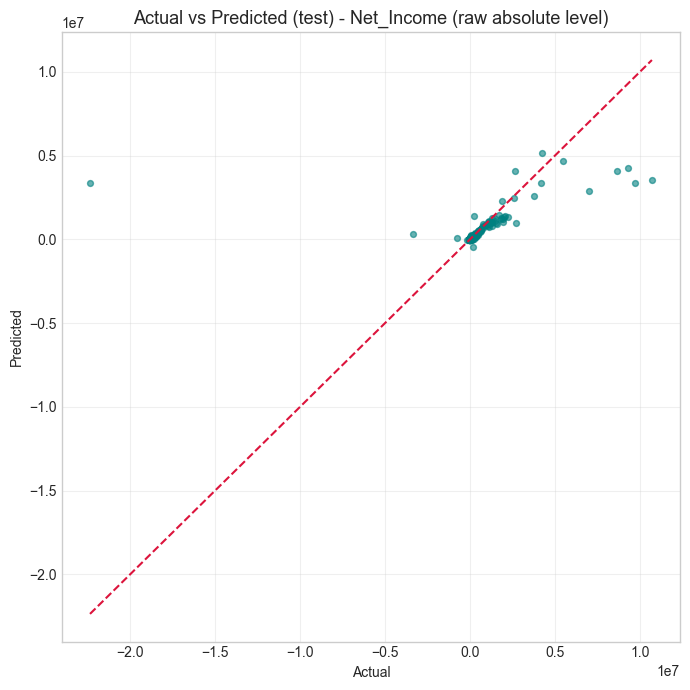

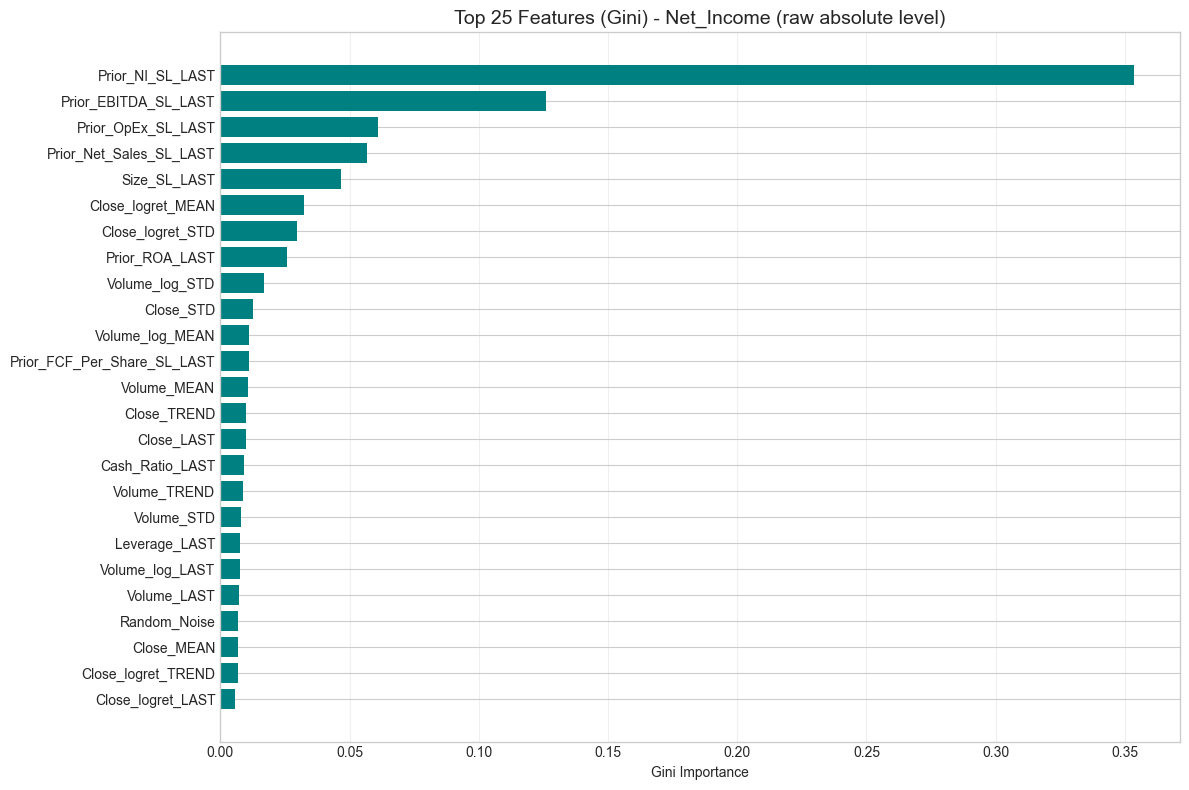

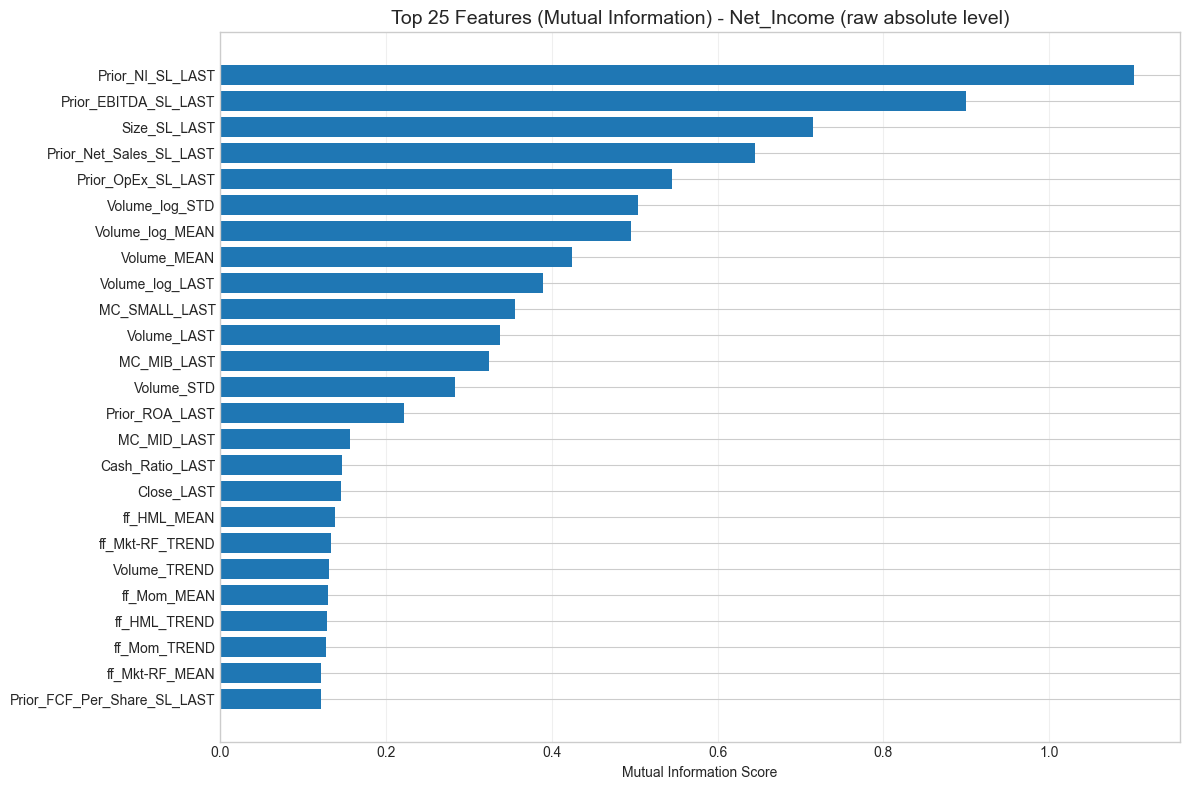

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_84565/562266529.py:170: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[te], plot_type='dot', show=False)


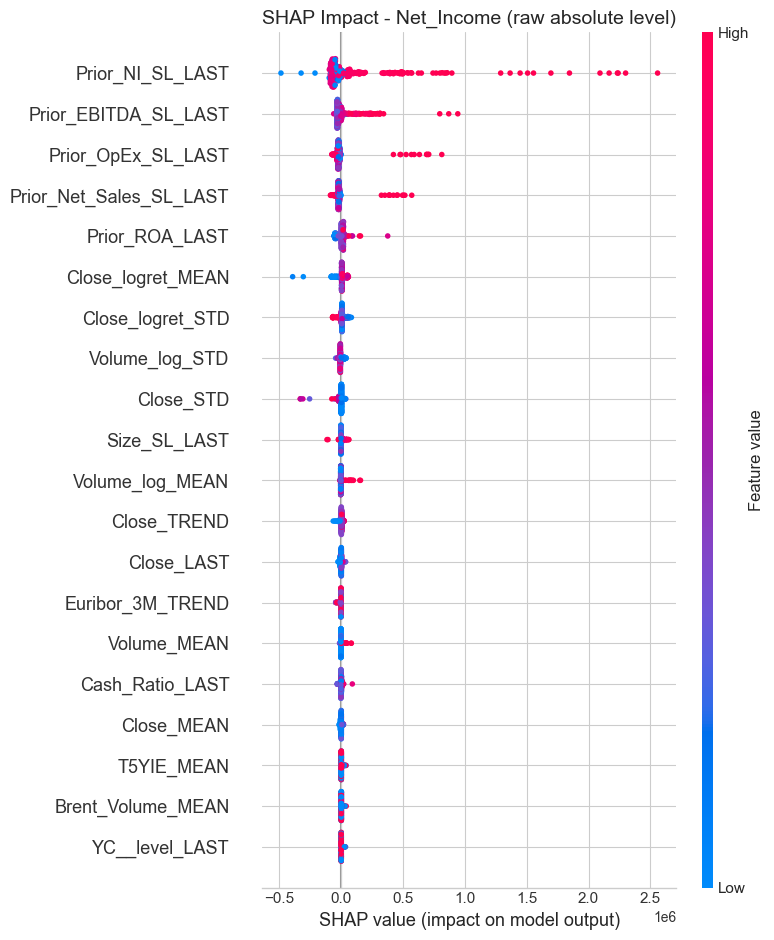


                         ROA (raw absolute level)                         
samples: train=1744 (<= 2022), val=172 (2023), test=342 (> 2023)
best params: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 16, 'criterion': 'absolute_error', 'bootstrap': True}
val  -> MAE 0.0272 | RMSE 0.0556 | R2 +0.6137 | WAPE 48.5%
test -> MAE 0.0352 | RMSE 0.1111 | R2 +0.3104 | WAPE 58.6%
top-8 Gini: Prior_ROA_LAST (0.504), Close_TREND (0.047), Close_logret_STD (0.030), Leverage_LAST (0.024), Close_logret_MEAN (0.024), Close_logret_LAST (0.017), Close_LAST (0.017), Close_MEAN (0.016)


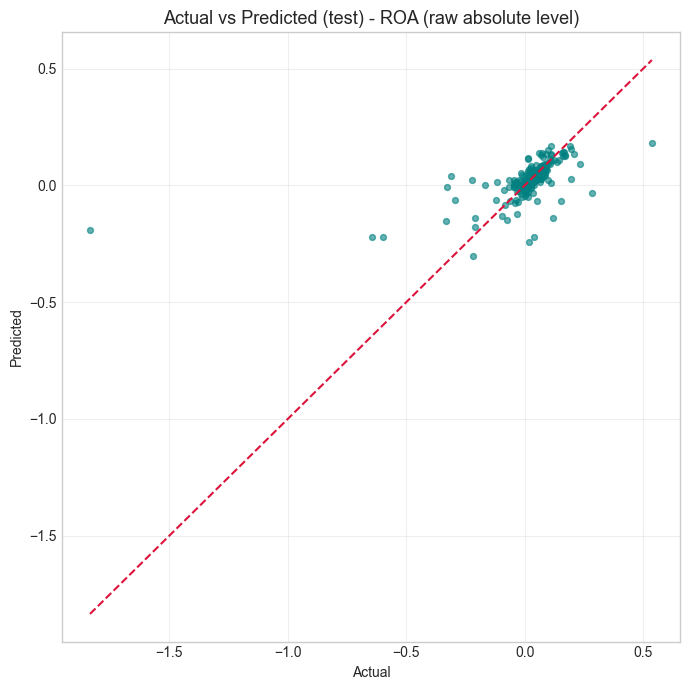

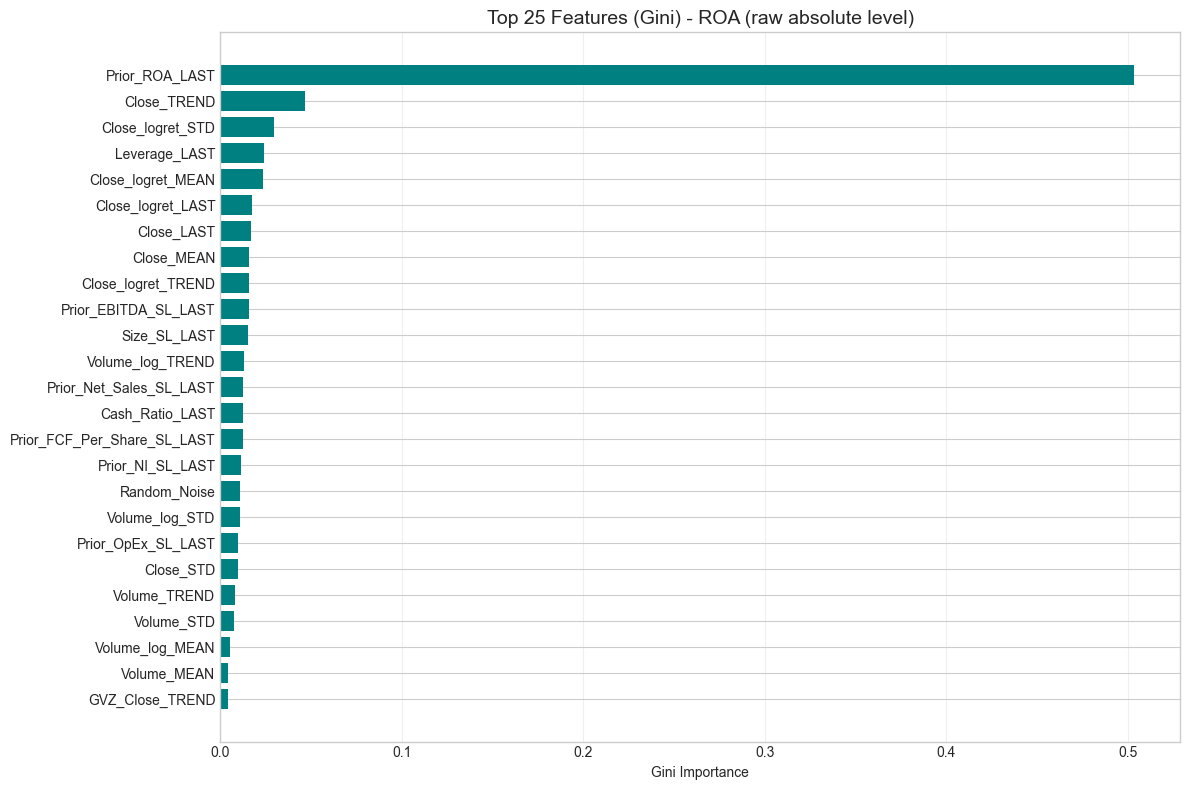

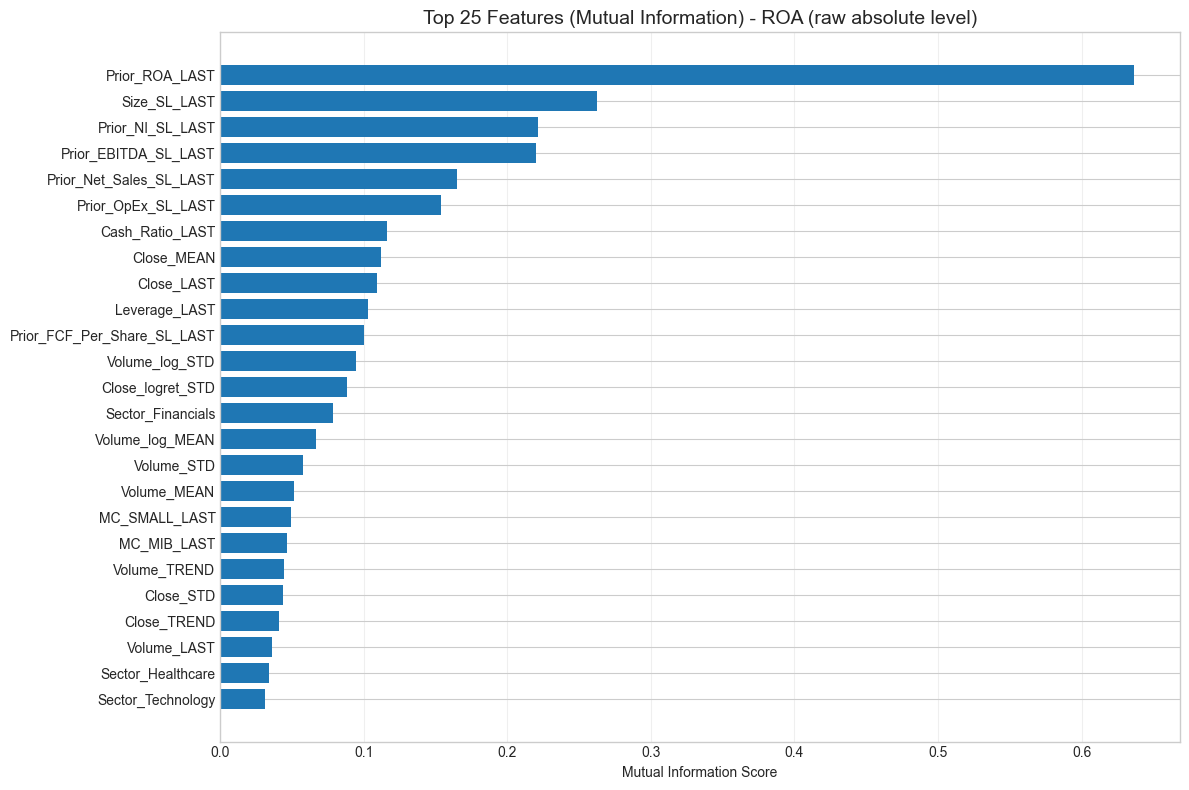

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_84565/562266529.py:170: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[te], plot_type='dot', show=False)


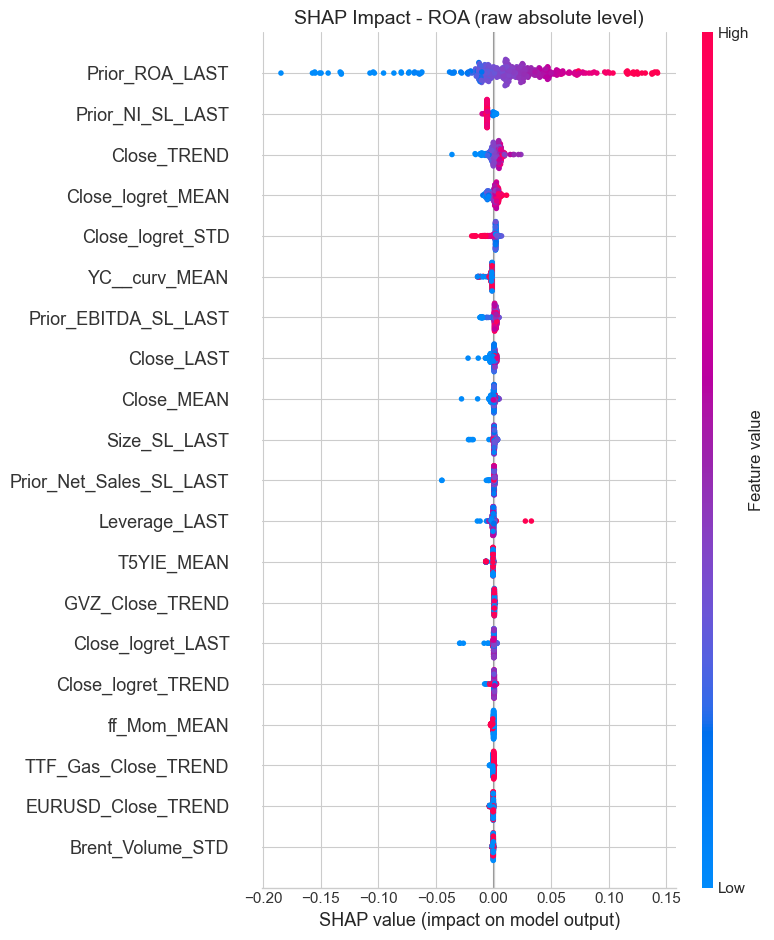


Summary (motivation only - the modeling targets are A and B):
    Target  Test_R2  Test_WAPE_%
    EBITDA 0.603948    31.593395
Net_Income 0.205179    49.649287
       ROA 0.310423    58.646379


In [ ]:
# raw ABSOLUTE targets
abs_summary = []
for t in PREDICTION_TARGETS:
    sub = (df.loc[df[t].notna(), ["Company", "year", "Date", t]]
             .sort_values(["Company", "year", "Date"])
             .drop_duplicates(["Company", "year"], keep="last")
             .rename(columns={"Date": "year_end_date"}).reset_index(drop=True))
    sub = sub[[window_available(r.Company, r.year_end_date) for r in sub.itertuples()]].reset_index(drop=True)
    X_df = extract_window_features(sub)
    X_df["__y"] = sub[t].to_numpy(float)
    res = run_rf_baseline(X_df, f"{t} (raw absolute level)")
    abs_summary.append({"Target": t,
                        "Test_R2": res["test"]["R2"],
                        "Test_WAPE_%": res["test"]["WAPE"]})
print("\nSummary (motivation only - the modeling targets are A and B):")
print(pd.DataFrame(abs_summary).to_string(index=False))


                      EBITDA (Target A: arcsinh-YoY)                      
samples: train=1680 (<= 2022), val=171 (2023), test=340 (> 2023)
best params: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 16, 'criterion': 'absolute_error', 'bootstrap': True}
val  -> MAE 0.5660 | RMSE 0.7846 | R2 +0.1956 | WAPE 82.2%
test -> MAE 0.5172 | RMSE 0.7630 | R2 +0.1611 | WAPE 90.6%
real space (0.5*sinh): val MAE 41.1% | test MAE 39.0%
naive: zero-forecast MAE val 0.6885 / test 0.5710 | AR(1) MAE val 0.6252 / test 0.5630 (n=334)
top-8 Gini: Prior_ROA_LAST (0.094), Prior_EBITDA_SL_LAST (0.085), Close_logret_MEAN (0.072), Close_logret_STD (0.067), Prior_NI_SL_LAST (0.060), Close_TREND (0.048), Close_logret_TREND (0.029), Cash_Ratio_LAST (0.029)


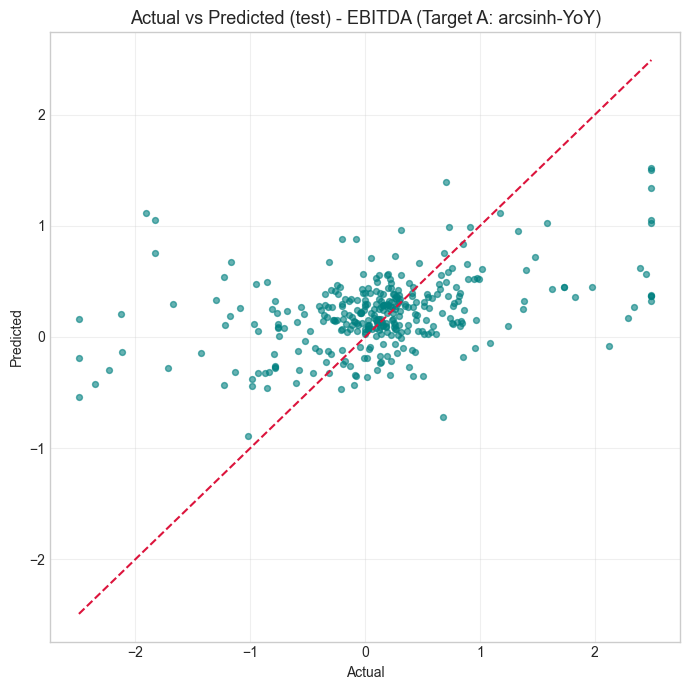

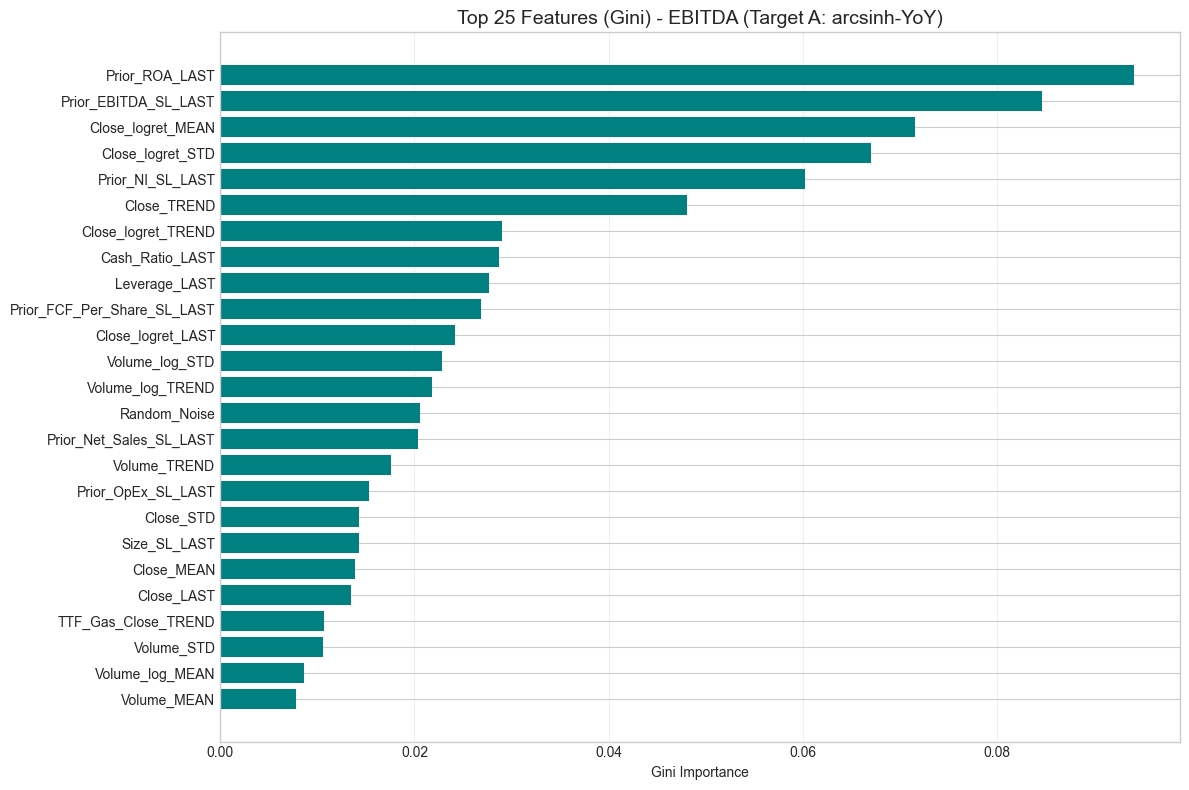

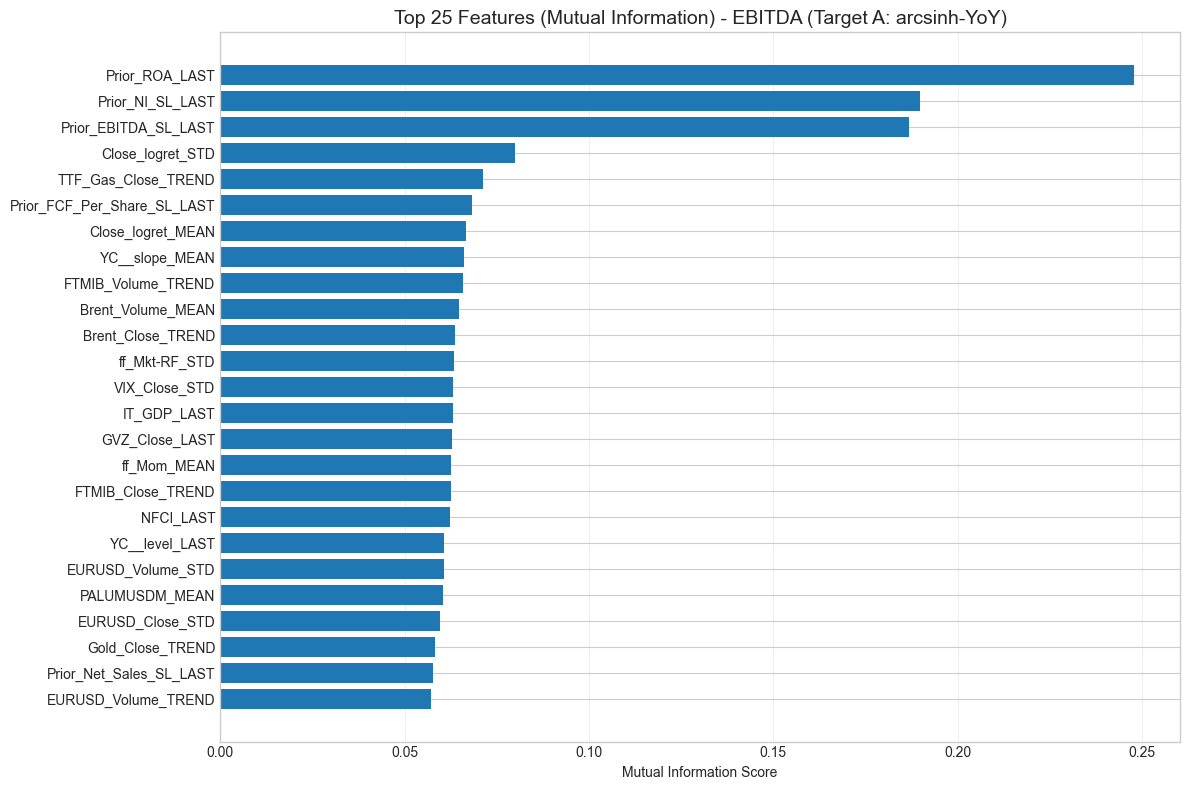

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_84565/2333357430.py:170: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[te], plot_type='dot', show=False)


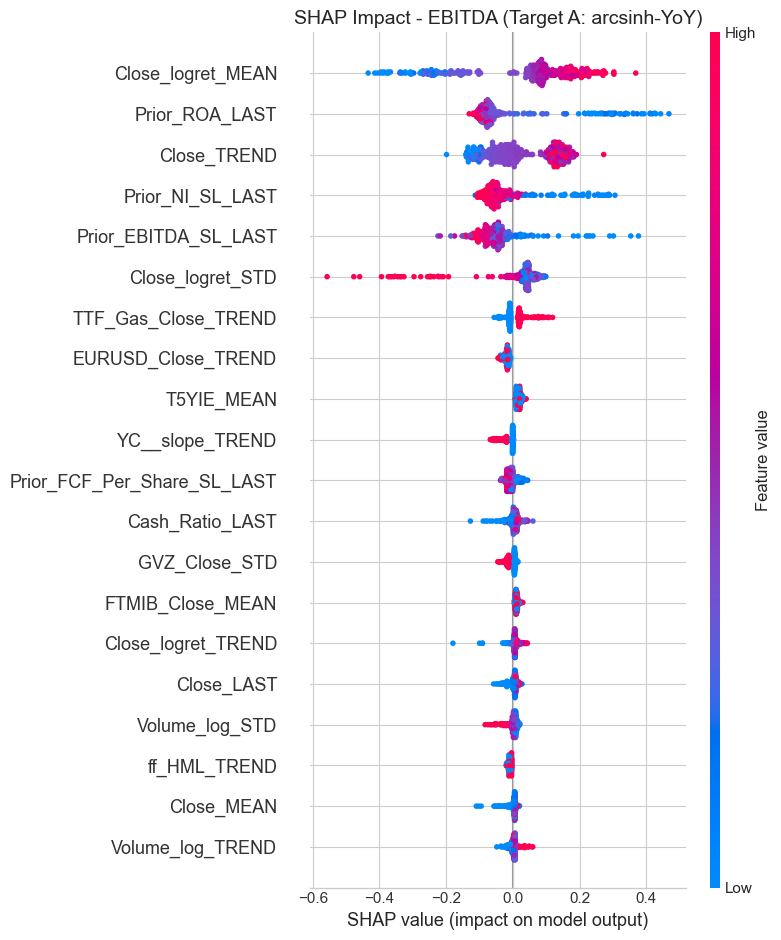


                    Net_Income (Target A: arcsinh-YoY)                    
samples: train=1680 (<= 2022), val=171 (2023), test=340 (> 2023)
best params: {'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': None, 'criterion': 'squared_error', 'bootstrap': True}
val  -> MAE 0.7497 | RMSE 0.9870 | R2 +0.3227 | WAPE 79.7%
test -> MAE 0.7695 | RMSE 1.0644 | R2 +0.0875 | WAPE 93.1%
real space (0.5*sinh): val MAE 65.4% | test MAE 62.9%
naive: zero-forecast MAE val 0.9406 / test 0.8268 | AR(1) MAE val 0.9201 / test 0.8217 (n=334)
top-8 Gini: Prior_ROA_LAST (0.121), Prior_NI_SL_LAST (0.094), Close_TREND (0.076), Close_logret_MEAN (0.070), Close_logret_STD (0.067), Prior_EBITDA_SL_LAST (0.030), Close_logret_TREND (0.028), Prior_FCF_Per_Share_SL_LAST (0.025)


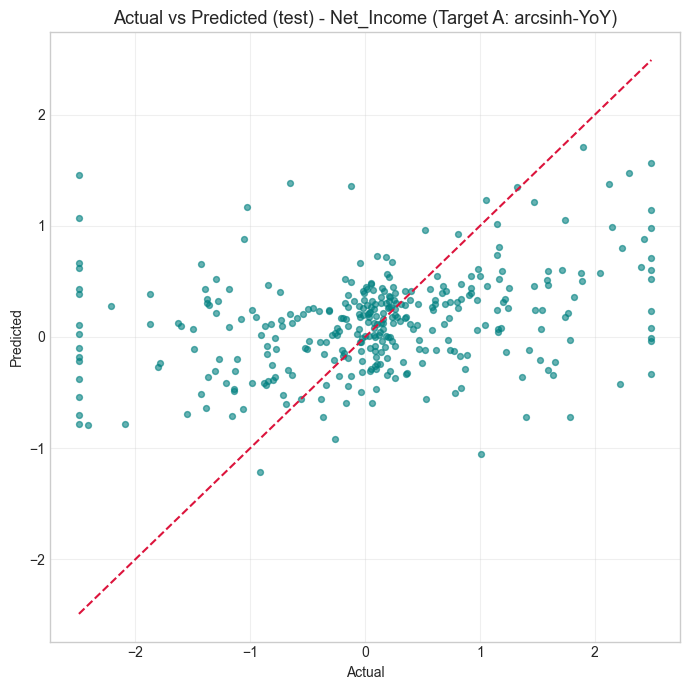

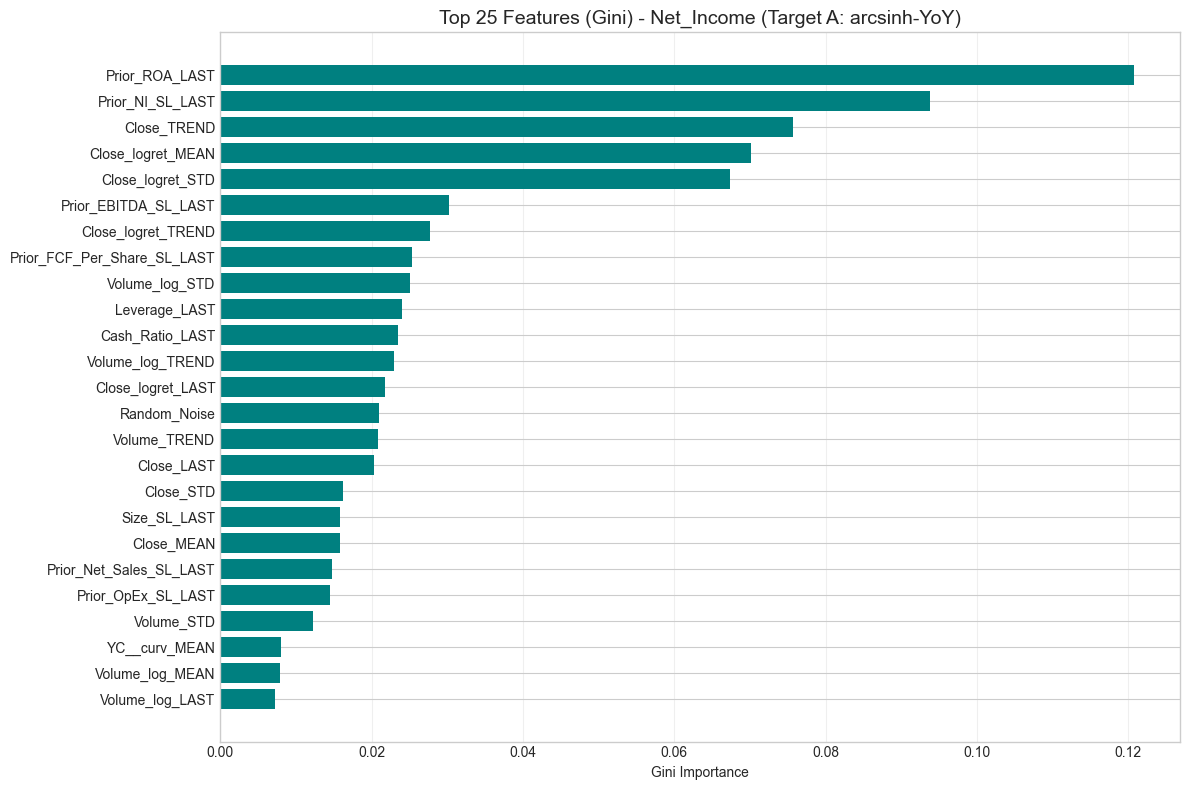

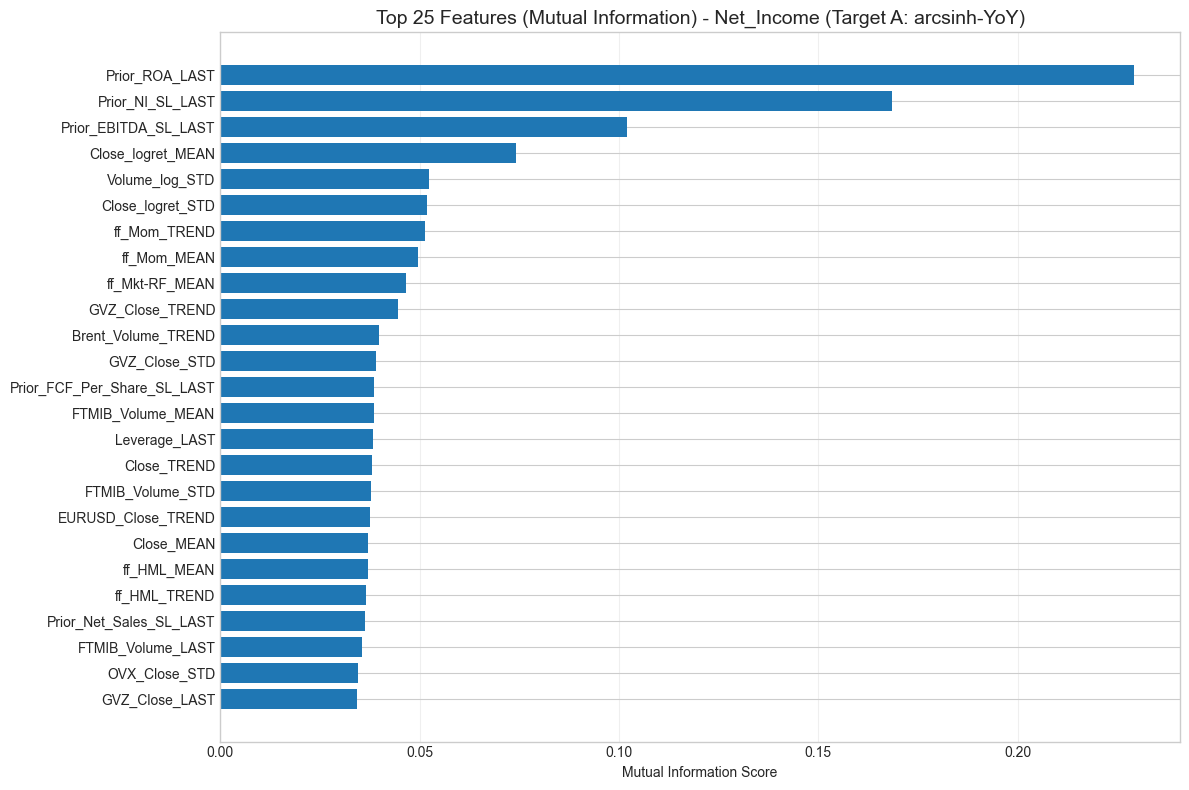

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_84565/2333357430.py:170: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[te], plot_type='dot', show=False)


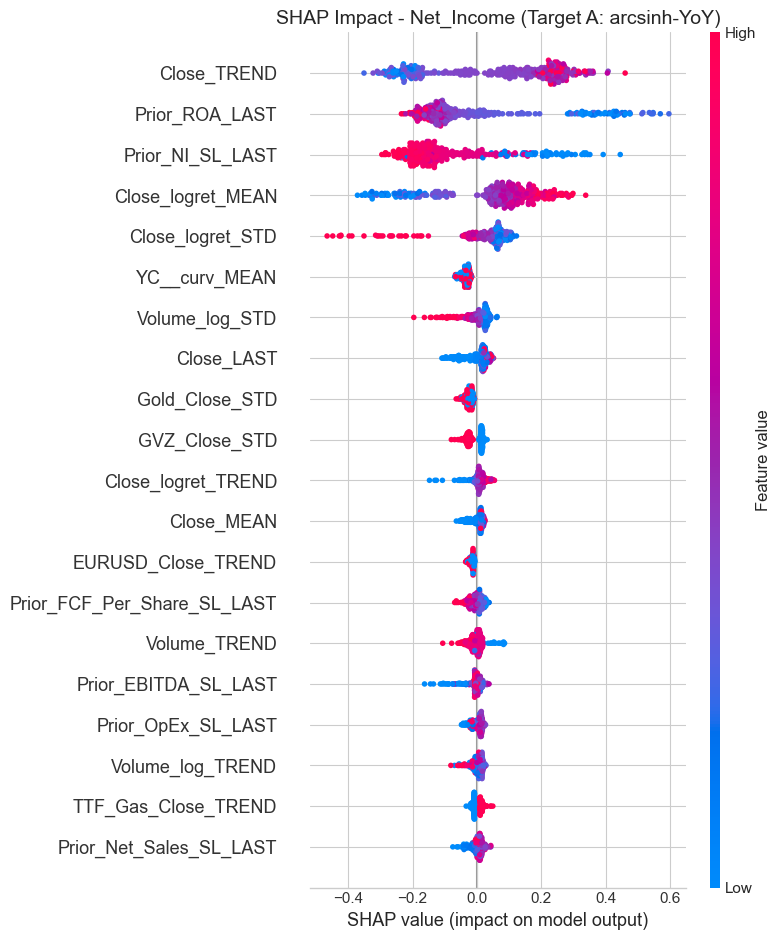


                       ROA (Target A: arcsinh-YoY)                        
samples: train=1680 (<= 2022), val=171 (2023), test=340 (> 2023)
best params: {'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 0.5, 'max_depth': 32, 'criterion': 'squared_error', 'bootstrap': True}
val  -> MAE 0.7726 | RMSE 1.0103 | R2 +0.3045 | WAPE 82.2%
test -> MAE 0.7490 | RMSE 1.0333 | R2 +0.1008 | WAPE 94.1%
real space (0.5*sinh): val MAE 67.5% | test MAE 60.6%
naive: zero-forecast MAE val 0.9394 / test 0.7956 | AR(1) MAE val 0.9303 / test 0.7940 (n=334)
top-8 Gini: Prior_ROA_LAST (0.128), Prior_NI_SL_LAST (0.092), Close_logret_MEAN (0.074), Close_TREND (0.069), Close_logret_STD (0.056), Prior_EBITDA_SL_LAST (0.029), Close_logret_TREND (0.026), Volume_log_STD (0.023)


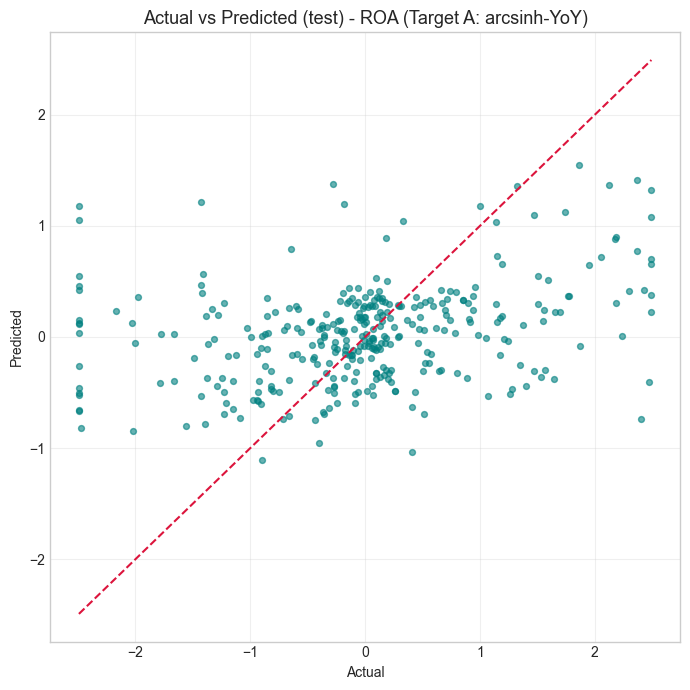

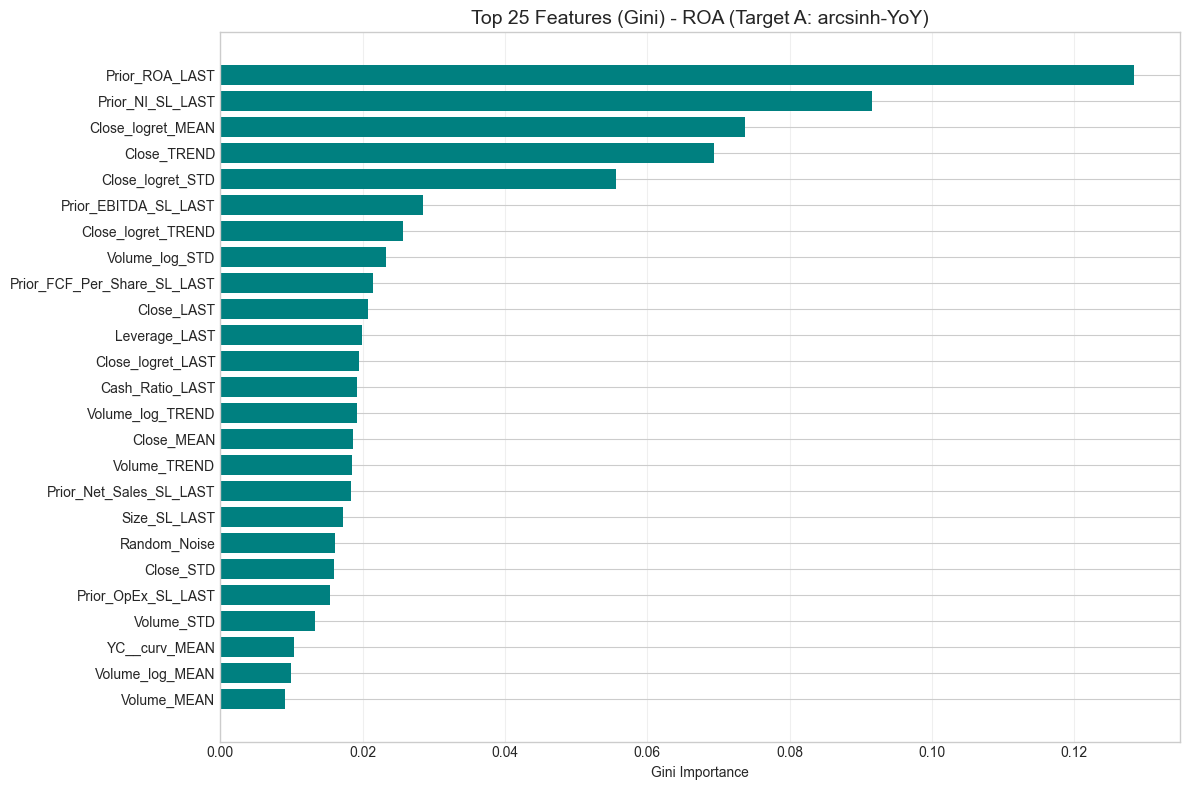

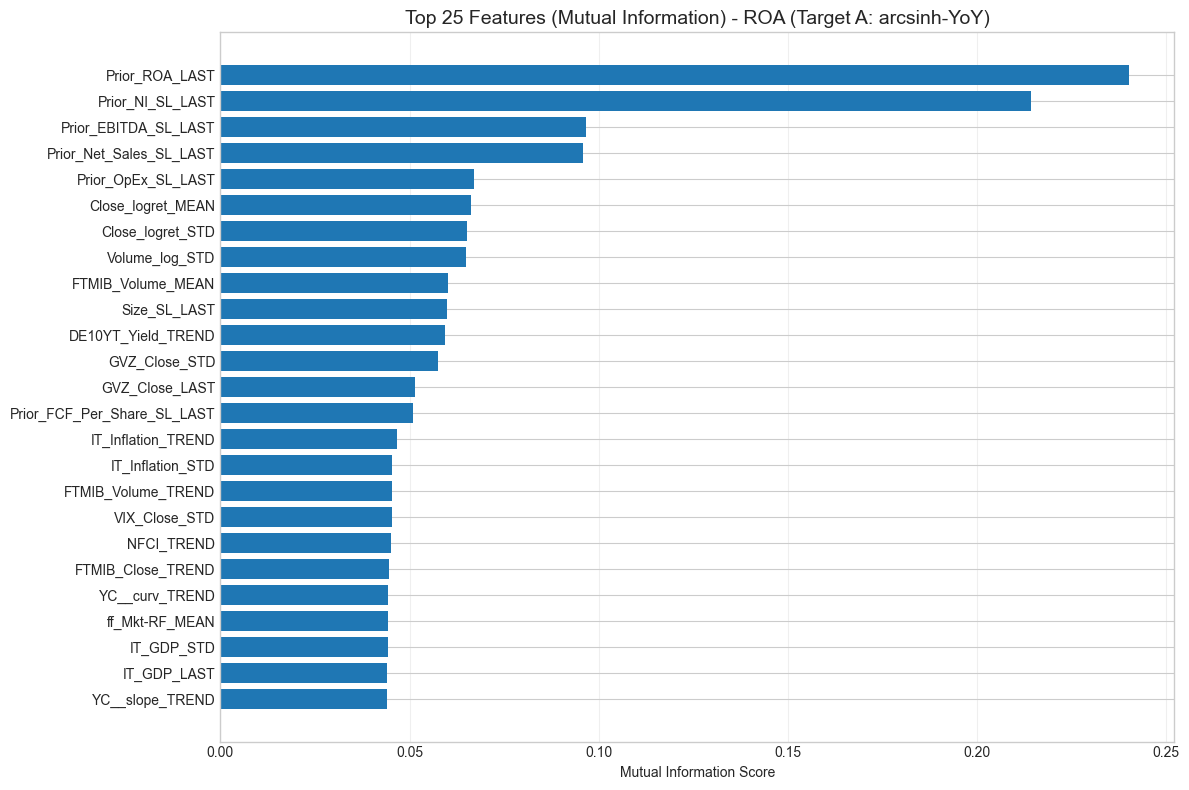

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_84565/2333357430.py:170: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[te], plot_type='dot', show=False)


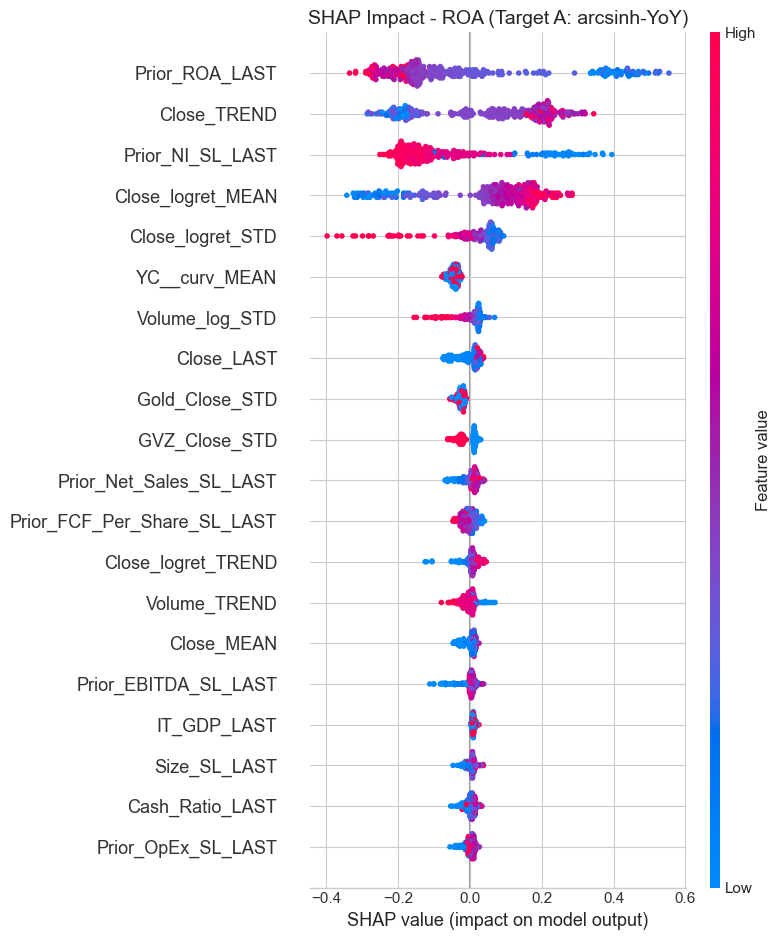


Target A summary (test > 2023):
    Target  Test MAE (asinh)  Test MAE (real %)  Test R2  Naive MAE (zero)  Naive MAE (AR1)  RF beats naive
    EBITDA          0.517225          38.952849 0.161084          0.571011         0.562972            True
Net_Income          0.769518          62.895720 0.087472          0.826815         0.821652            True
       ROA          0.749013          60.637049 0.100800          0.795567         0.794042            True


In [ ]:
# regression (winsor +-3 -> arcsinh c=0.5) 
asinh_summary = []
for t in PREDICTION_TARGETS:
    X_df = extract_window_features(samples_a)
    X_df["__y"] = samples_a[t].to_numpy(float)
    prev_map = panel_a[panel_a["target"] == t].set_index(["Company", "year"])["yoy_asinh_prev"]
    X_df["__lag"] = [prev_map.get((c, int(yr)), np.nan)
                     for c, yr in zip(samples_a["Company"], samples_a["year"])]
    res = run_rf_baseline(X_df, f"{t} (Target A: arcsinh-YoY)",
                          real_inverse=asinh_inverse, naive_lag_col="__lag")
    nt = res["naive"]["test"]
    asinh_summary.append({
        "Target": t,
        "Test MAE (asinh)": res["test"]["MAE"],
        "Test MAE (real %)": res["test_real"]["MAE"] * 100.0,
        "Test R2": res["test"]["R2"],
        "Naive MAE (zero)": nt["MAE_zero"],
        "Naive MAE (AR1)": nt["MAE_AR1"],
        "RF beats naive": res["test"]["MAE"] < min(nt["MAE_zero"], nt["MAE_AR1"]),
    })

print("\nTarget A summary (test > 2023):")
print(pd.DataFrame(asinh_summary).to_string(index=False))


                      EBITDA (Target B: delta-ratio)                      
samples: train=1660 (<= 2022), val=168 (2023), test=338 (> 2023)
best params: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 32, 'criterion': 'absolute_error', 'bootstrap': True}
val  -> MAE 0.0593 | RMSE 0.1022 | R2 +0.2760 | WAPE 87.9%
test -> MAE 0.0672 | RMSE 0.1337 | R2 +0.2336 | WAPE 103.1%
naive: zero-forecast MAE val 0.0675 / test 0.0652 | AR(1) MAE val 0.0669 / test 0.0645 (n=333)
top-8 Gini: Lag_d_prev_EBITDA (0.146), Lag_ratio_prev_EBITDA (0.113), Prior_EBITDA_SL_LAST (0.051), Close_logret_STD (0.042), Close_logret_MEAN (0.041), Prior_ROA_LAST (0.039), Leverage_LAST (0.035), Prior_NI_SL_LAST (0.034)


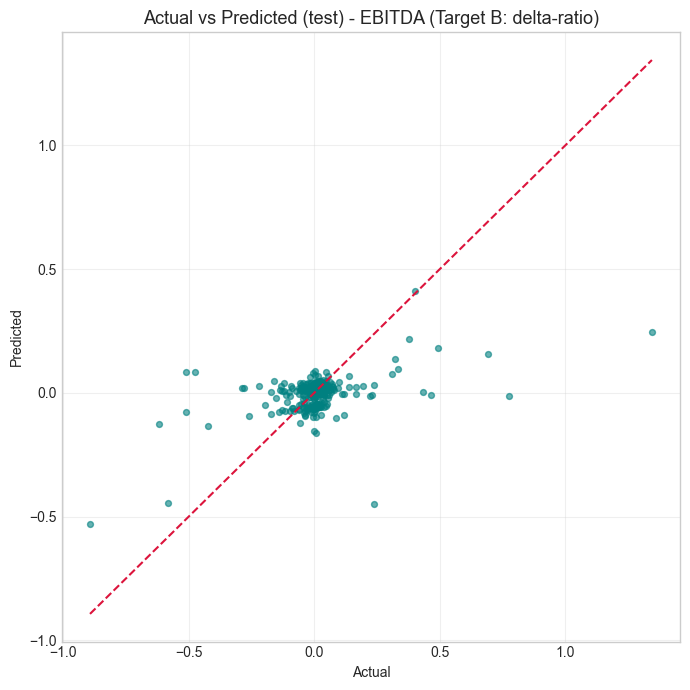

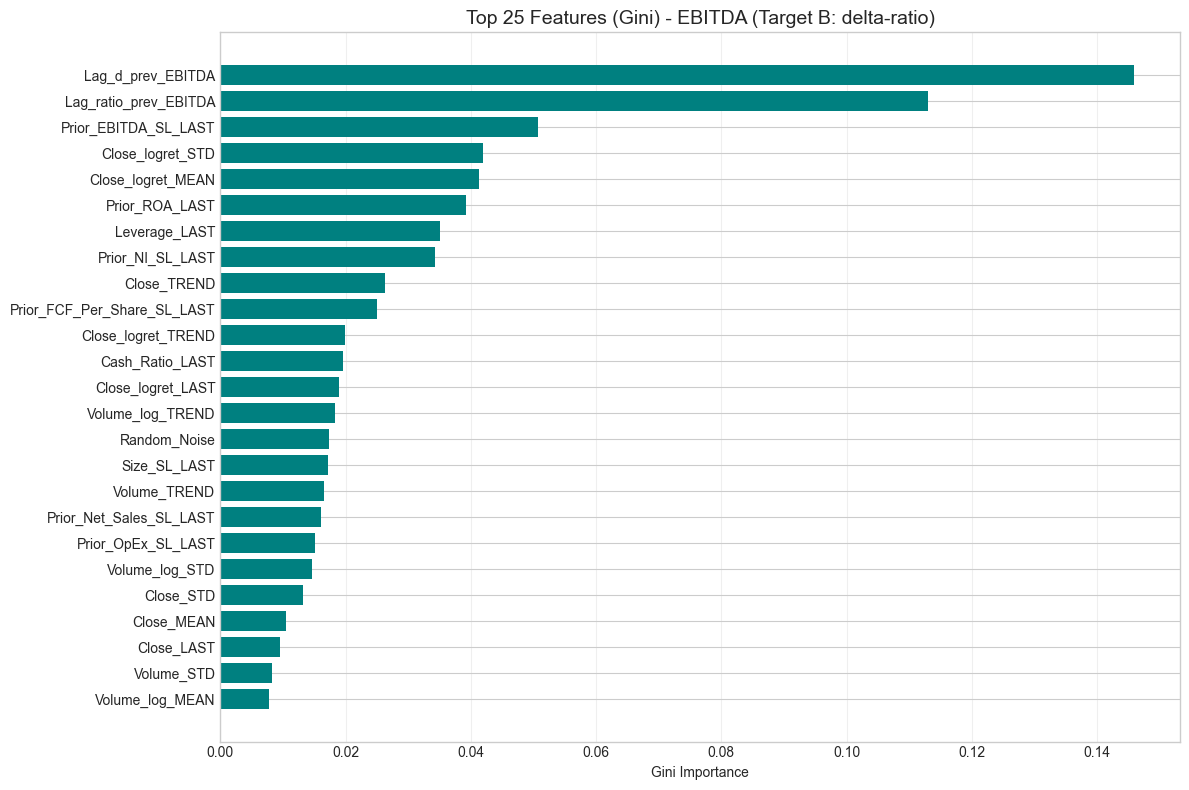

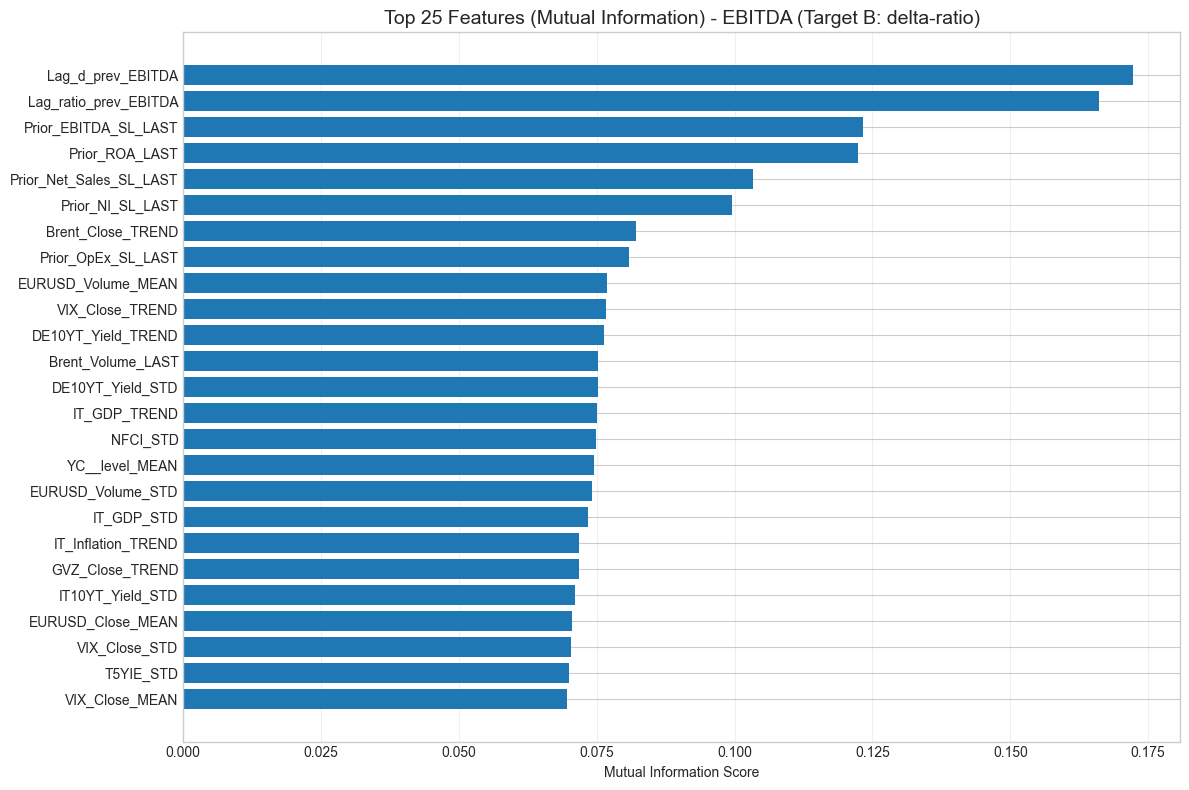

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_84565/2333357430.py:170: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[te], plot_type='dot', show=False)


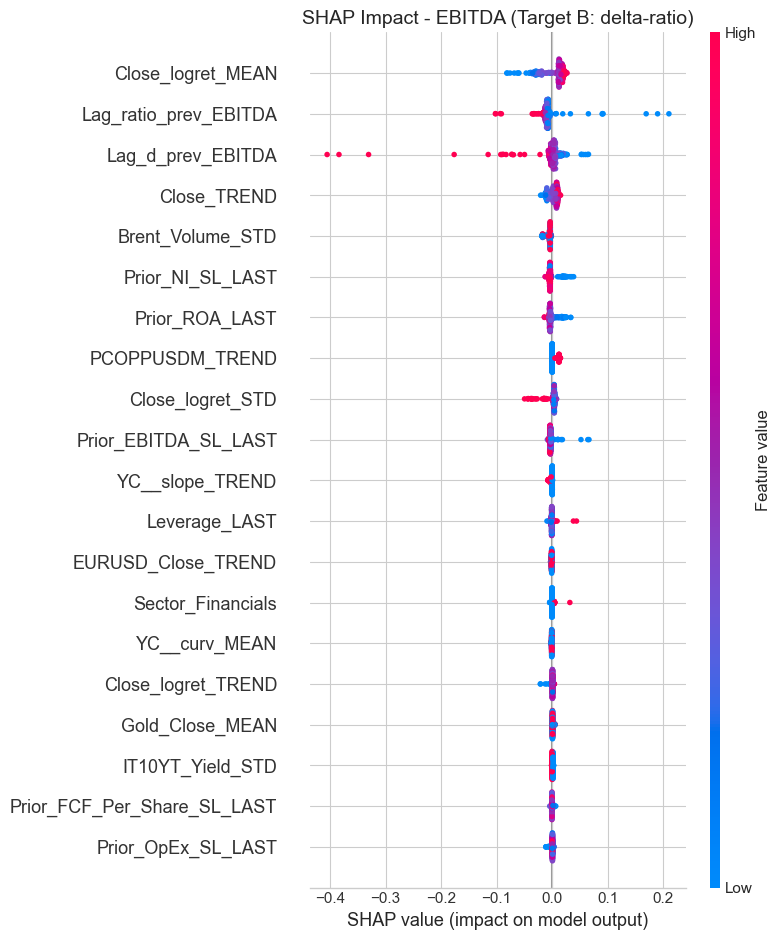


                    Net_Income (Target B: delta-ratio)                    
samples: train=1660 (<= 2022), val=168 (2023), test=338 (> 2023)
best params: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 32, 'criterion': 'absolute_error', 'bootstrap': True}
val  -> MAE 0.0521 | RMSE 0.0935 | R2 +0.3030 | WAPE 82.4%
test -> MAE 0.0613 | RMSE 0.1324 | R2 +0.1394 | WAPE 100.9%
naive: zero-forecast MAE val 0.0633 / test 0.0607 | AR(1) MAE val 0.0698 / test 0.0607 (n=333)
top-8 Gini: Lag_ratio_prev_Net_Income (0.225), Lag_d_prev_Net_Income (0.128), Leverage_LAST (0.039), Prior_ROA_LAST (0.037), Close_logret_STD (0.033), Close_logret_MEAN (0.030), Prior_EBITDA_SL_LAST (0.028), Close_TREND (0.026)


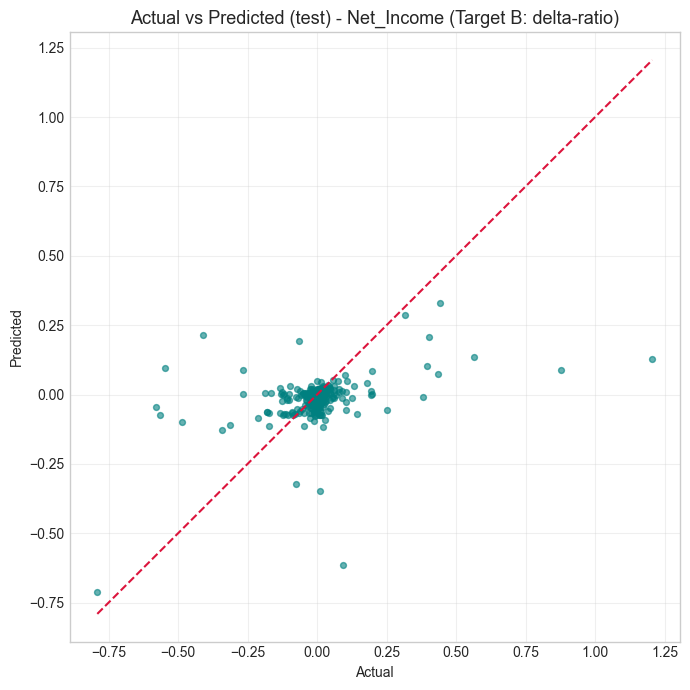

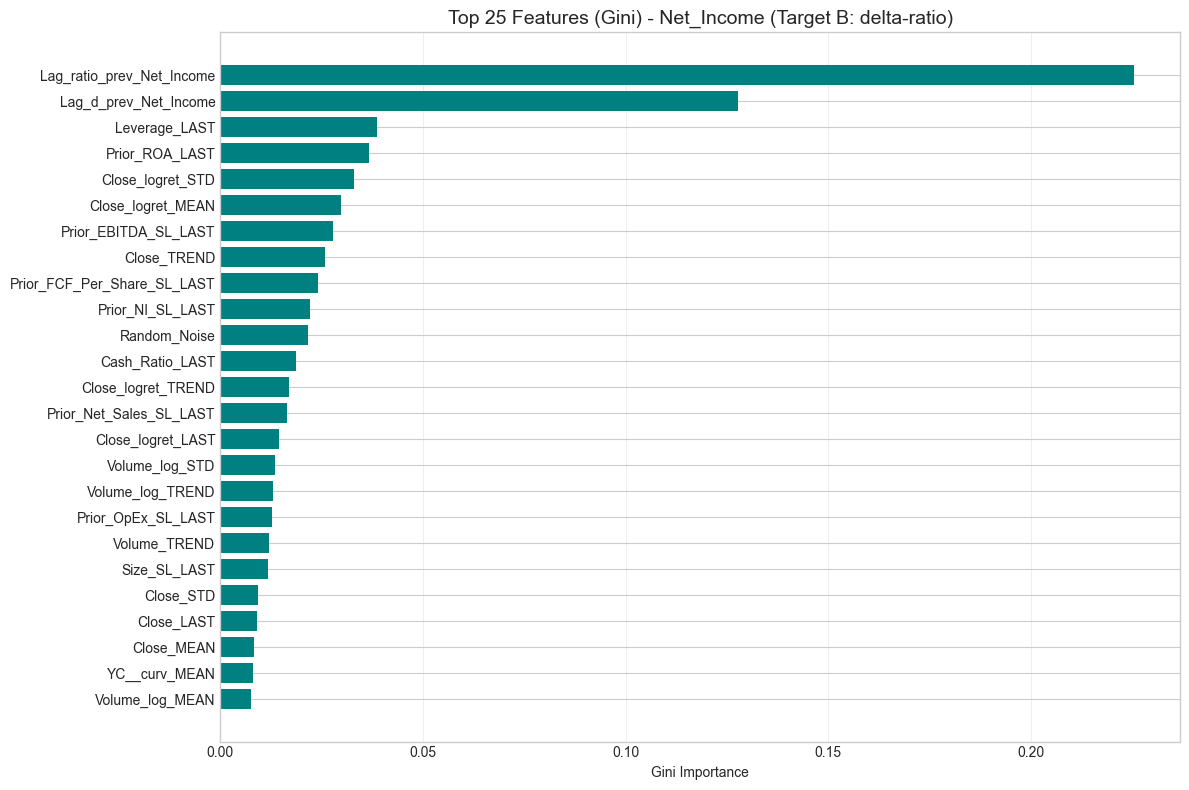

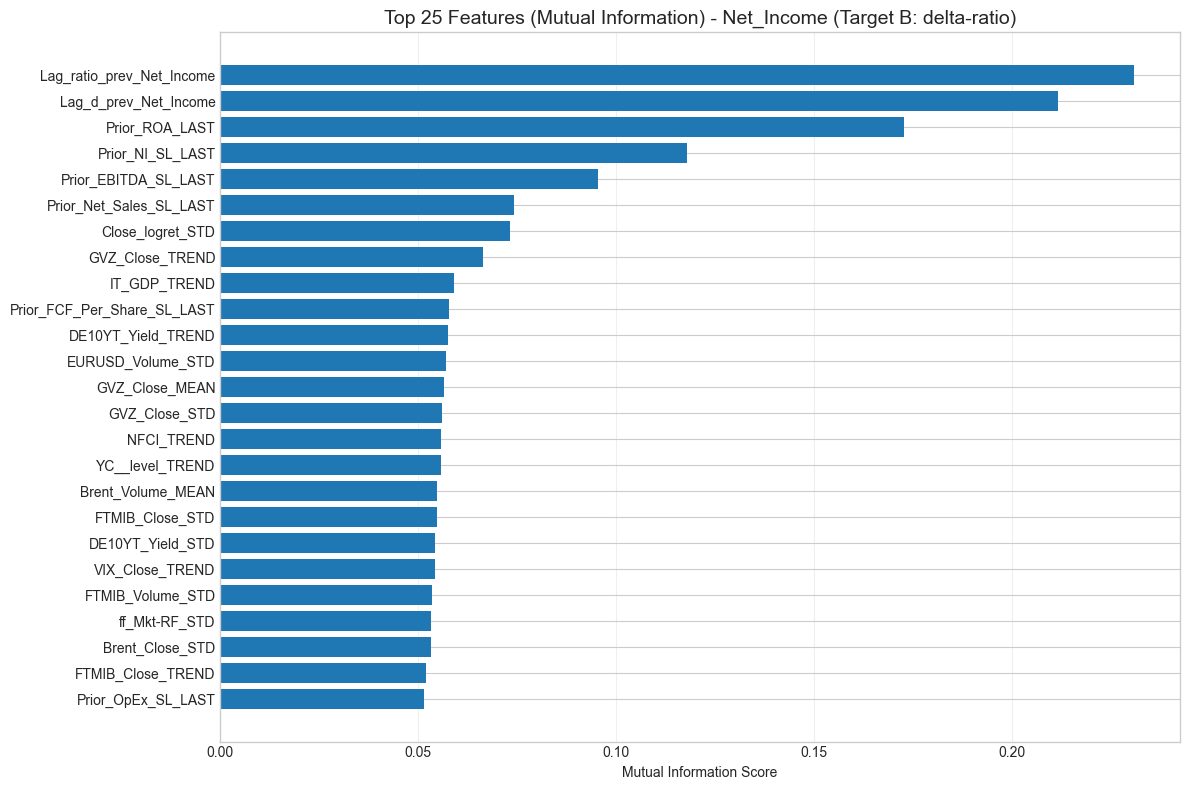

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_84565/2333357430.py:170: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[te], plot_type='dot', show=False)


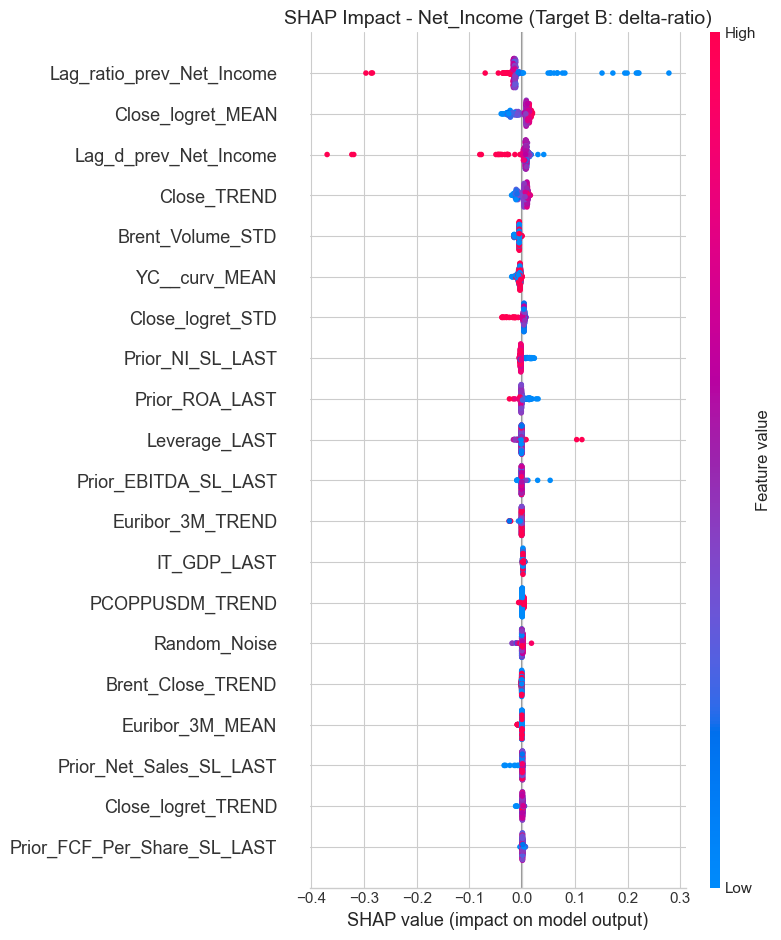


                       ROA (Target B: delta-ratio)                        
samples: train=1660 (<= 2022), val=168 (2023), test=338 (> 2023)
best params: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 16, 'criterion': 'absolute_error', 'bootstrap': True}
val  -> MAE 0.0269 | RMSE 0.0433 | R2 +0.4133 | WAPE 88.7%
test -> MAE 0.0273 | RMSE 0.0546 | R2 +0.1927 | WAPE 96.2%
naive: zero-forecast MAE val 0.0304 / test 0.0284 | AR(1) MAE val 0.0293 / test 0.0285 (n=333)
top-8 Gini: Prior_ROA_LAST (0.133), Lag_ratio_prev_ROA (0.098), Lag_d_prev_ROA (0.087), Close_TREND (0.050), Close_logret_STD (0.043), Close_logret_TREND (0.038), Close_logret_MEAN (0.038), Leverage_LAST (0.034)


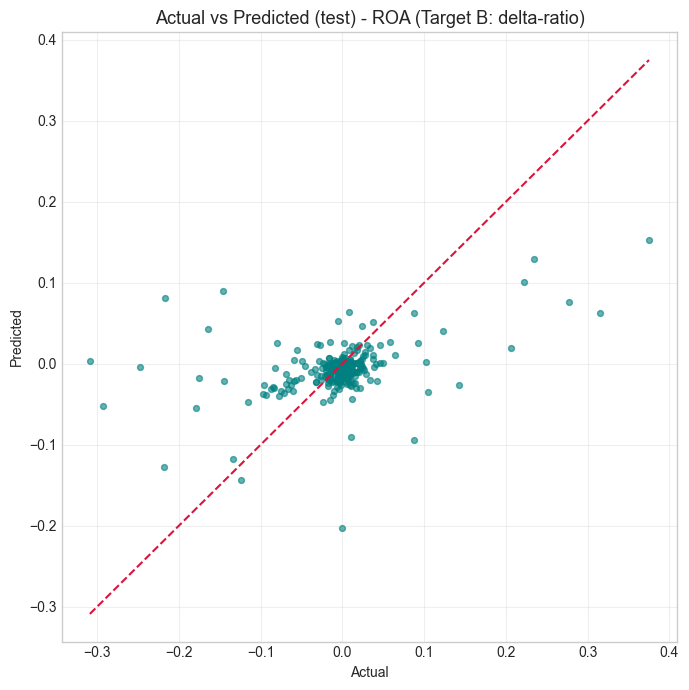

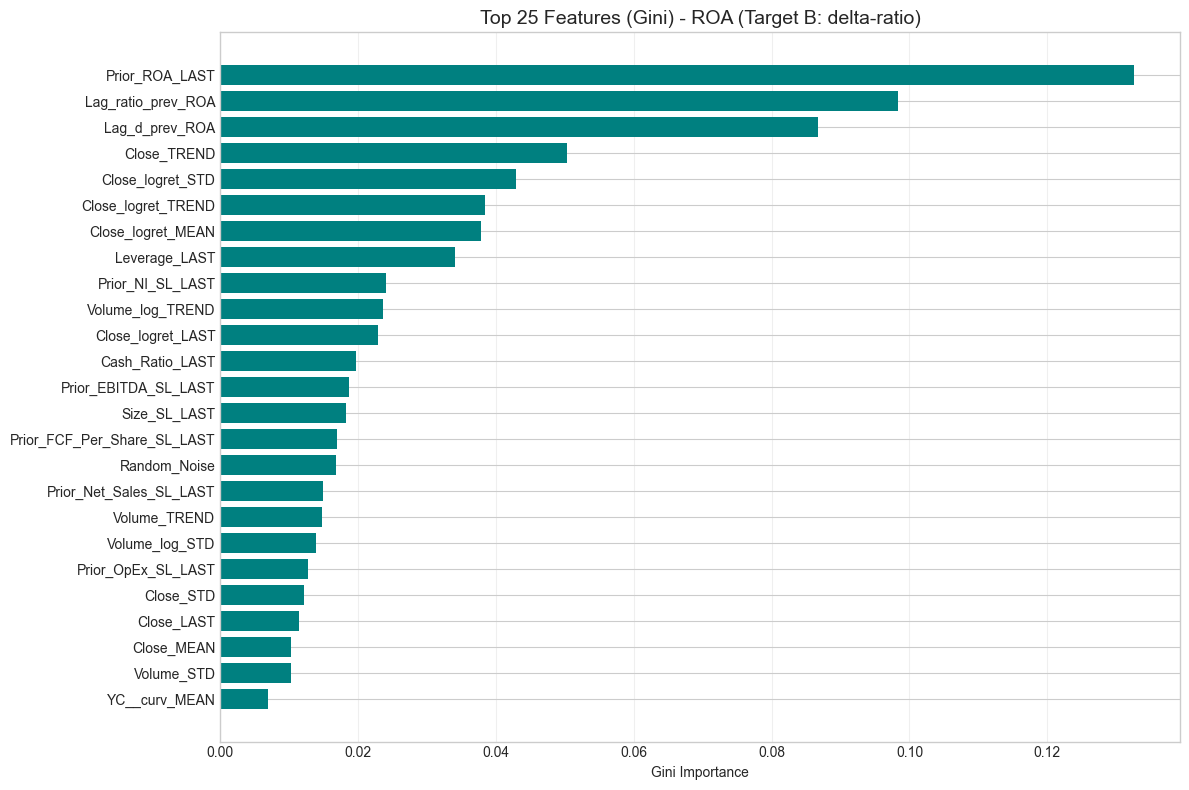

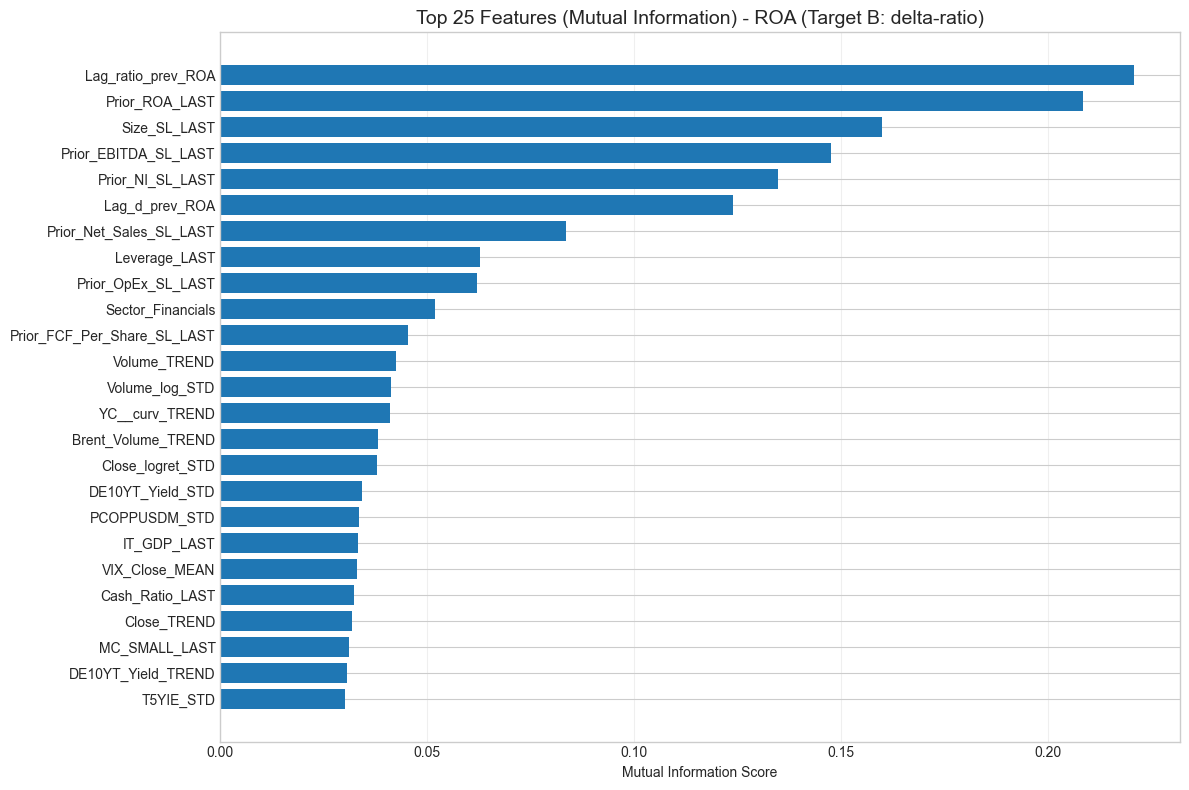

/var/folders/2r/ghvxl7bs1m5_fn9s5zhhbxzr0000gn/T/ipykernel_84565/2333357430.py:170: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[te], plot_type='dot', show=False)


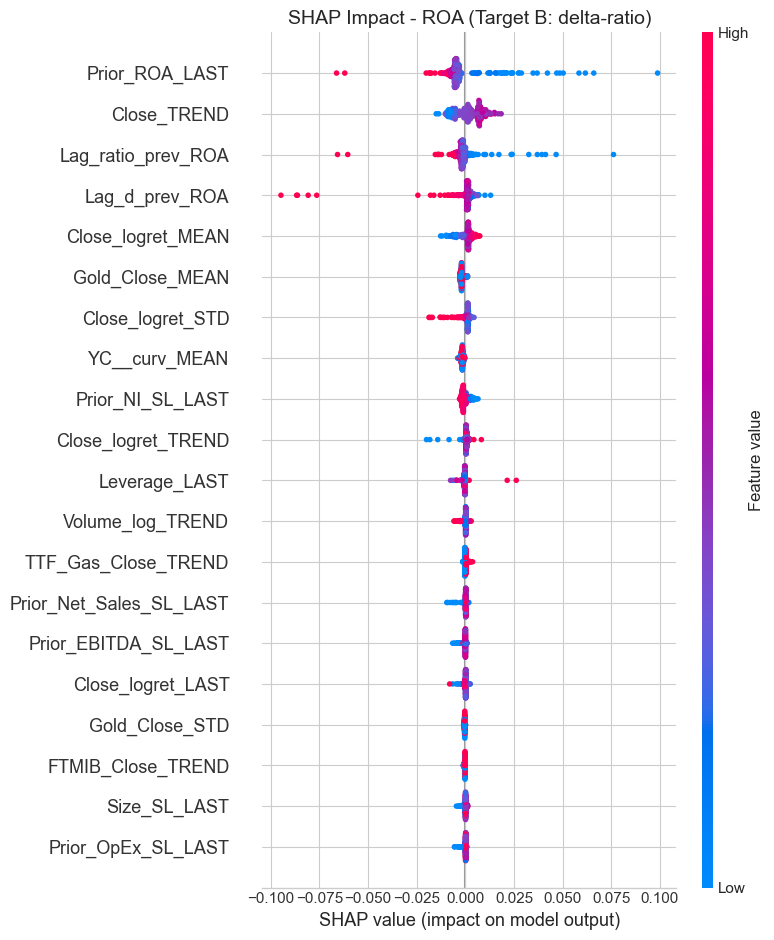


Target B summary (test > 2023):
    Target  Test MAE  Test R2  Test WAPE %  Naive MAE (zero)  Naive MAE (AR1)  RF beats naive
    EBITDA  0.067227 0.233584   103.121264          0.065192         0.064530           False
Net_Income  0.061272 0.139390   100.897633          0.060727         0.060681           False
       ROA  0.027292 0.192654    96.159074          0.028382         0.028543            True


In [ ]:
# regression (delta of winsorized size-normalized ratio)
delta_summary = []
for t in PREDICTION_TARGETS:
    X_df = extract_window_features(samples_b)
    pb = panel_b[panel_b["target"] == t]
    m_rp = pb.set_index(["Company", "year"])["ratio_prev"]
    m_dp = pb.set_index(["Company", "year"])["d_ratio_prev"]
    X_df[f"Lag_ratio_prev_{t}"] = [m_rp.get((c, int(yr)), np.nan)
                                   for c, yr in zip(samples_b["Company"], samples_b["year"])]
    X_df[f"Lag_d_prev_{t}"] = [m_dp.get((c, int(yr)), np.nan)
                               for c, yr in zip(samples_b["Company"], samples_b["year"])]
    X_df["__y"] = samples_b[t].to_numpy(float)
    X_df["__lag"] = X_df[f"Lag_d_prev_{t}"]
    res = run_rf_baseline(X_df, f"{t} (Target B: delta-ratio)", naive_lag_col="__lag")
    nt = res["naive"]["test"]
    delta_summary.append({
        "Target": t,
        "Test MAE": res["test"]["MAE"],
        "Test R2": res["test"]["R2"],
        "Test WAPE %": res["test"]["WAPE"],
        "Naive MAE (zero)": nt["MAE_zero"],
        "Naive MAE (AR1)": nt["MAE_AR1"],
        "RF beats naive": res["test"]["MAE"] < min(nt["MAE_zero"], nt["MAE_AR1"]),
    })

print("\nTarget B summary (test > 2023):")
print(pd.DataFrame(delta_summary).to_string(index=False))

## GroupedLSTM correlation-grouping

Clustering on 1680 train-year windows (Target A sample frame), 27 selected features.


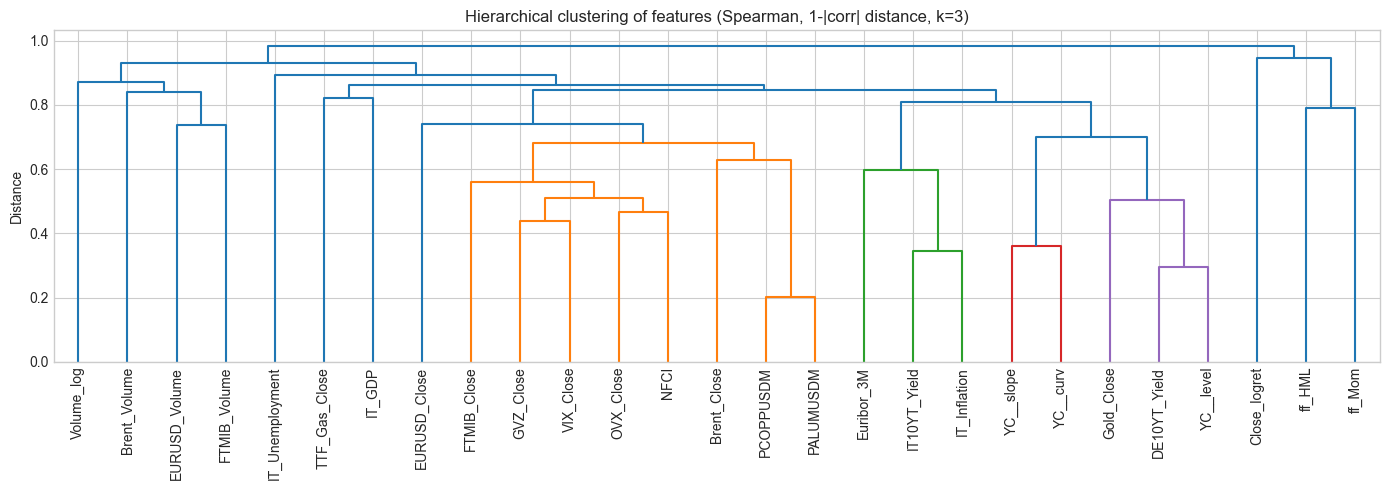

Group 1 (24): ['Volume_log', 'DE10YT_Yield', 'IT10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'FTMIB_Close', 'FTMIB_Volume', 'GVZ_Close', 'Brent_Close', 'Brent_Volume', 'OVX_Close', 'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv', 'TTF_Gas_Close', 'NFCI', 'Euribor_3M', 'IT_Inflation', 'IT_Unemployment', 'PCOPPUSDM', 'PALUMUSDM', 'IT_GDP']
Group 2 (2): ['ff_HML', 'ff_Mom']
Group 3 (1): ['Close_logret']


In [21]:
GROUPED_K = 3
SELECTED_FEATURES = DAILY_FEATURES + MONTHLY_FEATURES + QUARTERLY_FEATURES


def aggregate_to_cadence(window_days, raw_window, columns, n_steps):
    out = np.full((n_steps, len(columns)), np.nan, dtype=np.float32)
    T = raw_window.shape[0]
    if T < 2:
        return out
    last_day = float(window_days[-1])
    if last_day <= 0:
        return out
    bin_size = last_day / n_steps
    bin_idx = np.minimum((window_days / bin_size).astype(int), n_steps - 1)
    for f_i in range(len(columns)):
        col = raw_window[:, f_i]
        for b in range(n_steps):
            mask = bin_idx == b
            if mask.any():
                vals = col[mask]
                vals = vals[~np.isnan(vals)]
                if len(vals) > 0:
                    out[b, f_i] = vals[-1]
    return out


def build_daily_window(cdf_window, columns, n_daily=252):
    days = (cdf_window["Date"] - cdf_window["Date"].iloc[0]).dt.days.to_numpy()
    raw = cdf_window[columns].ffill().bfill().to_numpy(dtype=np.float32)
    d = aggregate_to_cadence(days, raw, columns, n_daily)
    d = pd.DataFrame(d).ffill().bfill().to_numpy()
    return np.nan_to_num(d, nan=0.0).astype(np.float32)


def compute_corr_groups(samples, columns, k=GROUPED_K, n_daily=252):
    pooled = []
    for row in samples.itertuples():
        cdf = df_by_company[row.Company]
        start = row.year_end_date - pd.Timedelta(days=LOOKBACK_DAYS)
        w = cdf[(cdf["Date"] > start) & (cdf["Date"] <= row.year_end_date)]
        if len(w) < MIN_WINDOW_OBS:
            continue
        d = build_daily_window(w, columns, n_daily)
        mu = d.mean(axis=0, keepdims=True)
        sd = d.std(axis=0, keepdims=True) + 1e-8
        pooled.append((d - mu) / sd)
    X = np.vstack(pooled)
    corr = pd.DataFrame(X).corr(method="spearman").to_numpy()
    corr = np.nan_to_num(corr, nan=0.0)
    dist = 1.0 - np.abs(corr)
    np.fill_diagonal(dist, 0.0)
    Z = linkage(squareform(dist), method="average")
    labels = fcluster(Z, t=k, criterion="maxclust")
    groups = [[columns[i] for i in range(len(columns)) if labels[i] == c]
              for c in sorted(set(labels))]

    plt.figure(figsize=(14, 5))
    dendrogram(Z, labels=columns, leaf_rotation=90)
    plt.title(f"Hierarchical clustering of features (Spearman, 1-|corr| distance, k={k})")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()
    return groups


samples_g = samples_a[samples_a["year"] <= TEST_YEAR_CUTOFF - 1].reset_index(drop=True)
print(f"Clustering on {len(samples_g)} train-year windows (Target A sample frame), "
      f"{len(SELECTED_FEATURES)} selected features.")
corr_groups = compute_corr_groups(samples_g, SELECTED_FEATURES)
for i, gset in enumerate(corr_groups, 1):
    print(f"Group {i} ({len(gset)}): {gset}")

## Cadence

In [ ]:
def modeling_group(feat):
    if feat in DAILY_FEATURES:
        return "Daily"
    if feat in MONTHLY_FEATURES:
        return "Monthly"
    if feat in QUARTERLY_FEATURES:
        return "Quarterly"
    return "(not used by MultiFreq)"

data_end = df["Date"].max()
audit_rows = []
for feat in CONTINUOUS_FEATURES:
    sub = df[["Date", feat]].dropna()
    nu_per_year = sub.groupby(sub["Date"].dt.year)[feat].nunique()
    med_nu = float(nu_per_year.median()) if len(nu_per_year) else np.nan
    gaps = sub.sort_values("Date")["Date"].diff().dt.days.dropna()
    max_gap = float(gaps.max()) if len(gaps) else np.nan
    nan_pct = 100.0 * df[feat].isna().mean()
    last_date = sub["Date"].max() if len(sub) else pd.NaT
    staleness = (data_end - last_date).days if pd.notna(last_date) else np.nan
    if np.isnan(med_nu):
        observed = "(no data)"
    elif med_nu >= 40:
        observed = "Daily"
    elif med_nu >= 8:
        observed = "Monthly"
    elif med_nu >= 2:
        observed = "Quarterly"
    else:
        observed = "(constant)"
    audit_rows.append({
        "Feature": feat,
        "NaN %": round(nan_pct, 2),
        "Median distinct vals/yr": round(med_nu, 1) if not np.isnan(med_nu) else np.nan,
        "Max gap (d)": round(max_gap, 1) if not np.isnan(max_gap) else np.nan,
        "Last obs": str(last_date.date()) if pd.notna(last_date) else "-",
        "Stale (d)": staleness,
        "Observed cadence": observed,
        "Modeling group": modeling_group(feat),
    })

audit_df = pd.DataFrame(audit_rows)
print(f"Dataset end: {data_end.date()}\n")
print(audit_df.to_string(index=False))

used = audit_df[~audit_df["Modeling group"].str.contains("not used", na=False)]
mismatch = used[used["Observed cadence"] != used["Modeling group"]]
print("\nMismatches between observed cadence and the modeling frequency assignment:")
print(mismatch.to_string(index=False) if len(mismatch) else "  none")

n_daily = len(DAILY_FEATURES)
n_monthly = len(MONTHLY_FEATURES)
n_quarterly = len(QUARTERLY_FEATURES)
print(f"\nModeling split: {n_daily} daily / {n_monthly} monthly / {n_quarterly} quarterly "
      f"(MultiFreqLSTM_NoQuarterly folds '{QUARTERLY_FEATURES[0]}' into the monthly stream).")

Dataset end: 2025-12-30

        Feature  NaN %  Median distinct vals/yr  Max gap (d)   Last obs  Stale (d) Observed cadence          Modeling group
          Close   0.00                  13879.0          6.0 2025-12-30          0            Daily (not used by MultiFreq)
         Volume   0.00                  14755.0          6.0 2025-12-30          0            Daily (not used by MultiFreq)
   DE10YT_Yield   0.00                    212.0          6.0 2025-12-30          0            Daily                   Daily
   EURUSD_Close   0.00                    225.0          6.0 2025-12-30          0            Daily                   Daily
  EURUSD_Volume   0.00                    254.0          6.0 2025-12-30          0            Daily                   Daily
     Euribor_3M   0.00                     12.0          6.0 2025-12-30          0          Monthly                 Monthly
    FTMIB_Close   0.00                    253.0          6.0 2025-12-30          0            Daily        